# 🛍️ Stage 4 — Complete A/B Testing Masterclass
## E-commerce Experimentation: From Experiment Design to Business Decision

---

> 📌 **Tamil:** "A/B Testing என்பது இரண்டு versions-ஐ compare பண்ணி எது better என்று data மூலம் prove பண்ணுவது.  
> Google daily 10,000+ A/B tests run பண்ணுது. இந்த notebook-ல் complete A/B testing pipeline learn பண்ணுவோம்."

---

Version A → Orange Button
Version B → Green Button

Question:
👉 "Green button அதிக conversion(மாற்றம்) தருகிறதா?"

இதற்கு guess பண்ணாமல் data + statistics மூலம் answer கண்டுபிடிப்பதே A/B Testing.

---

### 5 Complete A/B Testing Projects

| # | Project | Dataset | Test | Business Question |
|---|---------|---------|------|-------------------|
| 1 | Button color test | `ab_button.csv` | Two-proportion z-test | Does green beat orange CTA? |
| 2 | Pricing page layout | `ab_pricing.csv` | Chi-square test | Which layout drives more upgrades? |
| 3 | Email subject line | `ab_email.csv` | Proportion z-test | Which subject gets more opens? |
| 4 | Checkout flow | `ab_checkout.csv` | Two-tail z-test + CUPED | Does simplified flow reduce drop-off? |
| 5 | Multi-variant test | `ab_multivariant.csv` | Chi-square + post-hoc | Best of 4 homepage variants? |

### Full Pipeline in Every Project
```
Define MDE → Calculate sample size → Design experiment → 
Collect data → Check validity → Run test → Make business decision
```

---

| Step                       | தமிழ் விளக்கம்                                                   | Example                                 |
| -------------------------- | ---------------------------------------------------------------- | --------------------------------------- |
| **Define MDE**             | எவ்வளவு improvement வந்தால் business-க்கு பயன் என்று முடிவு செய் | Conversion 10% → 12% (MDE = 2%)         |
| **Calculate Sample Size**  | Test செய்ய எத்தனை users வேண்டும் என்று கணக்கு போடு               | A = 4000 users, B = 4000 users          |
| **Design Experiment**      | Users-ஐ random ஆக groups-ஆக பிரி                                 | 50% Control (A), 50% Treatment (B)      |
| **Collect Data**           | Experiment run செய்து data சேகரி                                 | A: 500 conversions, B: 620 conversions  |
| **Check Validity**         | Data சரியா, bias இல்லையா என சரிபார்                              | Missing data, bot traffic check         |
| **Run Test**               | Statistical test run செய்                                        | Two-Proportion Z-Test                   |
| **Make Business Decision** | Result அடிப்படையில் முடிவு எடு                                   | Green button conversion அதிகம் → Deploy |



## ⚙️ Step 0 — Imports & Global Helpers

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm, chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Palette ──────────────────────────────────────────────────────────────────
PURPLE = '#534AB7'; TEAL   = '#0F6E56'; AMBER  = '#BA7517'
CORAL  = '#993C1D'; BLUE   = '#185FA5'; DGRAY  = '#5F5E5A'
GREEN  = '#3B6D11'; LGRAY  = '#F1EFE8'

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FFFFFF',
    'axes.grid':True,'grid.alpha':0.25,'grid.linestyle':'--',
    'font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,
})

# ══════════════════════════════════════════════════════════════════════════════
# CORE A/B TESTING FUNCTIONS — used in every project
# ══════════════════════════════════════════════════════════════════════════════

def calc_sample_size(p_baseline, mde, alpha=0.05, power=0.80, tails=2):
    """Minimum sample size per group (two-proportion z-test)."""
    p2       = p_baseline + mde
    p_bar    = (p_baseline + p2) / 2
    z_alpha  = norm.ppf(1 - alpha / tails)
    z_beta   = norm.ppf(power)
    n = ((z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) +
          z_beta  * np.sqrt(p_baseline*(1-p_baseline) + p2*(1-p2))) ** 2) / mde**2
    return int(np.ceil(n))

def run_ab_test(conv_A, n_A, conv_B, n_B, alpha=0.05, tail='two'):
    """Two-proportion z-test. Returns full result dict."""
    p_A    = conv_A / n_A
    p_B    = conv_B / n_B
    p_pool = (conv_A + conv_B) / (n_A + n_B)
    se     = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))
    z      = (p_B - p_A) / se
    p_val  = (1 - norm.cdf(abs(z))) * (1 if tail=='one' else 2)
    cv     = norm.ppf(1 - alpha / (1 if tail=='one' else 2))
    lift   = (p_B - p_A) / p_A
    # 95% CI for the difference
    se_diff = np.sqrt(p_A*(1-p_A)/n_A + p_B*(1-p_B)/n_B)
    z_ci    = norm.ppf(0.975)
    ci      = ((p_B-p_A) - z_ci*se_diff, (p_B-p_A) + z_ci*se_diff)
    return {
        'p_A':p_A,'p_B':p_B,'p_pool':p_pool,'se':se,'z':z,
        'p_val':p_val,'cv':cv,'lift':lift,'ci':ci,
        'significant': p_val < alpha,
        'decision': 'SHIP ✅' if p_val < alpha and p_B > p_A else
                    ('DO NOT SHIP ❌' if p_val < alpha else 'INCONCLUSIVE 🔄')
    }

def print_result(r, name='A/B Test', alpha=0.05):
    print(f"{'═'*60}")
    print(f"  {name}")
    print(f"{'═'*60}")
    print(f"  Conversion A  : {r['p_A']:.4f} = {r['p_A']*100:.2f}%")
    print(f"  Conversion B  : {r['p_B']:.4f} = {r['p_B']*100:.2f}%")
    print(f"  Relative lift : {r['lift']:+.2%}")
    print(f"  Z-statistic   : {r['z']:.4f}")
    print(f"  p-value       : {r['p_val']:.4f}")
    print(f"  Critical value: ±{r['cv']:.4f}")
    print(f"  95% CI (diff) : ({r['ci'][0]*100:.3f}%, {r['ci'][1]*100:.3f}%)")
    print(f"  Significant?  : {'YES  (p < α)' if r['significant'] else 'NO   (p ≥ α)'}")
    print(f"  Decision      : {r['decision']}")

def plot_ab_curve(ax, z_stat, alpha=0.05, tail='two', title=''):
    """Draw annotated normal curve with rejection region."""
    x = np.linspace(-4, 4, 400)
    y = norm.pdf(x)
    ax.plot(x, y, color=DGRAY, linewidth=2)
    cv = norm.ppf(1 - alpha/(1 if tail=='one' else 2))
    zones = [cv] if tail=='one' else [-cv, cv]
    for c in zones:
        xf = x[x>=c] if c>0 else x[x<=c]
        ax.fill_between(xf, 0, norm.pdf(xf), color=CORAL, alpha=0.30)
        ax.axvline(c, color=CORAL, linewidth=1.5, linestyle='--',
                   label=f'cv = {c:.2f}')
    ax.axvline(z_stat, color=PURPLE, linewidth=2.5, label=f'z = {z_stat:.2f}')
    p_val = (1-norm.cdf(abs(z_stat))) * (1 if tail=='one' else 2)
    sig   = p_val < alpha
    ax.set_title(f'{title}\np={p_val:.4f} → {"REJECT H₀" if sig else "Fail to reject"}',
                 fontweight='bold', color=CORAL if sig else DGRAY, fontsize=10)
    ax.set_xlabel('z-statistic'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

print("✅  All A/B testing functions ready!")
print("   calc_sample_size()  — minimum n per group")
print("   run_ab_test()       — full z-test result dict")
print("   print_result()      — formatted output")
print("   plot_ab_curve()     — annotated normal curve")


✅  All A/B testing functions ready!
   calc_sample_size()  — minimum n per group
   run_ab_test()       — full z-test result dict
   print_result()      — formatted output
   plot_ab_curve()     — annotated normal curve


---
---
# 🎯 Project 1 — Button Color A/B Test (The Classic)
## E-commerce CTA: Orange vs Green "Buy Now" Button

---

### Business Problem
CTA = Call To Action User-ஐ ஒரு action செய்ய தூண்டும் button, link, அல்லது message.

Marketing believes changing the CTA button from **Orange (A)** to **Green (B)** will increase purchases.  
The product team asks: *Is a 0.6pp(percentage points) lift enough to justify the engineering effort?*

> 📌 **Tamil:** "Button color change பண்ணினால் conversion rate மாறுமா?  
> MDE → Sample size → Experiment → Test → Business decision — full pipeline."

### Full A/B Testing Pipeline
1. Define Minimum Detectable Effect (MDE) - குறைந்தபட்சம் 0.6% improvement வந்தால் change worth it."
2. Calculate required sample size - இந்த 0.6% difference detect செய்ய எத்தனை users வேண்டும்?
3. Generate experiment data - Users-ஐ random ஆக split செய்கிறோம்.
4. Validate experiment health (SRM check) - SRM = Sample Ratio Mismatch
5. Run statistical test - Two-Proportion Z-Test
6. Calculate business impact - Button color change மூலம் மாதத்திற்கு ₹1.2 லட்சம் கூடுதல் profit.
7. Make the shipping decision - 

| Condition          | Decision        |
| ------------------ | --------------- |
| p < 0.05 and B > A | SHIP ✅          |
| p < 0.05 and B < A | REJECT ❌        |
| p ≥ 0.05           | INCONCLUSIVE 🔄 |

Orange மற்றும் Green CTA buttons-ஐ A/B Testing மூலம் compare செய்தோம். 0.6% MDE define செய்து sample size calculate செய்தோம். Users-ஐ random-ஆக split செய்து SRM check செய்தோம். Two-Proportion Z-Test run செய்து p-value < 0.05 கிடைத்ததால் Green button statistically significant improvement கொடுத்தது. Business impact analysis-ல் additional revenue கிடைப்பது தெரிய வந்ததால் Green button deploy செய்ய முடிவு செய்தோம்.

In [ ]:
# ══ PHASE 1: EXPERIMENT DESIGN (before collecting any data) ══ A/B Test தொடங்கும் முன் எவ்வளவு data தேவை? என்பதை இந்த phase-ல் முடிவு செய்கிறோம்.
print("══ PHASE 1: EXPERIMENT DESIGN ══")
print()

p_baseline = 0.032   # current orange button conversion: 3.2% (Baseline Conversion Rate = 3.2%)
mde        = 0.006   # minimum detectable effect: 0.6pp (we care about this or bigger) - "0.6 percentage point அல்லது அதற்கு மேல் improvement இருந்தால் மட்டுமே button change செய்வது worth."
alpha      = 0.05    # significance level (5% false positive rate) - Button actually better இல்லாவிட்டாலும், 5% chance அதை better என்று தவறாக முடிவு செய்யலாம். இதுதான் False Positive Rate.
power      = 0.80    # statistical power (80% chance to detect real effect) - Green button உண்மையில் better இருந்தால், 80% probability அதை detect செய்ய முடியும்.
# மீதமுள்ள: 20% chance-ல் real improvement-ஐ miss பண்ணலாம் (False Negative).

n_required = calc_sample_size(p_baseline, mde, alpha, power, tails=2)

print(f"  Baseline conversion rate : {p_baseline:.1%}")
print(f"  Minimum Detectable Effect: {mde:.1%} absolute ({mde/p_baseline:.1%} relative)")
print(f"  Significance level (α)   : {alpha}")
print(f"  Statistical power (1-β)  : {power:.0%}")
print(f"  Required n per group     : {n_required:,}")
print(f"  Total users needed       : {n_required*2:,}")
print()
print(f"  ► If your site gets 5,000 visitors/day:")
print(f"    Experiment duration = {n_required*2/5000:.1f} days ≈ {n_required*2/5000/7:.1f} weeks")

# A Group = 14,727, B Group = 14,727 - Total: 29,454 users
# Meaning: Statistically reliable result பெற ,குறைந்தபட்சம் 29,454 users experiment-ல் பங்கேற்க வேண்டும்

# Website Traffic: 5,000 visitors/day - Need: 29,454 users
# Calculation: 29,454 / 5,000 = 5.9 days ≈ 6 days அல்லது 0.8 weeks

══ PHASE 1: EXPERIMENT DESIGN ══

  Baseline conversion rate : 3.2%
  Minimum Detectable Effect: 0.6% absolute (18.8% relative)
  Significance level (α)   : 0.05
  Statistical power (1-β)  : 80%
  Required n per group     : 14,727
  Total users needed       : 29,454

  ► If your site gets 5,000 visitors/day:
    Experiment duration = 5.9 days ≈ 0.8 weeks


In [ ]:
# ══ PHASE 2: GENERATE EXPERIMENT DATA ══
np.random.seed(42)
n_A = n_B = 5000   # 10,000 total users

# True conversion rates (what the button actually causes)
true_p_A, true_p_B = 0.032, 0.038

conversions_A = np.random.binomial(1, true_p_A, n_A)
conversions_B = np.random.binomial(1, true_p_B, n_B)

# Build detailed event log (like a real analytics system)
records = []
for g, convs, n in [('Control (Orange)', conversions_A, n_A),
                    ('Treatment (Green)', conversions_B, n_B)]:
    p_true = true_p_A if 'Control' in g else true_p_B
    for i, c in enumerate(convs):
        records.append({
            'user_id'       : f'U{len(records)+1:05d}',
            'group'         : g,
            'button_color'  : 'Orange' if 'Control' in g else 'Green',
            'converted'     : c,
            'session_pages' : np.random.poisson(3.5 + 0.5*c),
            'time_on_site_s': int(np.random.exponential(180 + 60*c)),
            'device'        : np.random.choice(['Mobile','Desktop','Tablet'],
                                               p=[0.62,0.30,0.08]),
            'traffic_source': np.random.choice(['Organic','Paid','Email','Social'],
                                               p=[0.35,0.30,0.20,0.15]),
        })

df_btn = pd.DataFrame(records)
df_btn.to_csv('ab_button.csv', index=False)

conv_A = df_btn[df_btn['group']=='Control (Orange)']['converted'].sum()
conv_B = df_btn[df_btn['group']=='Treatment (Green)']['converted'].sum()

print(f"✅ Dataset: ab_button.csv  ({len(df_btn):,} rows × {df_btn.shape[1]} cols)")
df_btn.head(8)


# | Column         | Meaning                   |
# | -------------- | ------------------------- |
# | user_id        | User identifier           |
# | group          | A/B group                 |
# | button_color   | Orange/Green              |
# | converted      | Purchase or not           |
# | session_pages  | Pages viewed              |
# | time_on_site_s | Time spent                |
# | device         | Mobile/Desktop/Tablet     |
# | traffic_source | Organic/Paid/Email/Social |

# | Source      | Meaning                          | Example                                     |
# | ----------- | -------------------------------- | ------------------------------------------- |
# | **Organic** | Search engine மூலம் free traffic | Google-ல் search செய்து website-க்கு வருதல் |
# | **Paid**    | Paid advertisements மூலம் வருதல் | Google Ads, Facebook Ads                    |
# | **Email**   | Email campaign மூலம் வருதல்      | Promotional email-ல் link click செய்தல்     |
# | **Social**  | Social media மூலம் வருதல்        | Facebook, Instagram, LinkedIn, X (Twitter)  |



✅ Dataset: ab_button.csv  (10,000 rows × 8 cols)


,user_id,group,button_color,converted,session_pages,time_on_site_s,device,traffic_source
0,U00001,Control (Orange),Orange,0,2,168,Mobile,Social
1,U00002,Control (Orange),Orange,0,1,259,Desktop,Social
2,U00003,Control (Orange),Orange,0,4,1,Mobile,Organic
3,U00004,Control (Orange),Orange,0,2,432,Mobile,Email
4,U00005,Control (Orange),Orange,0,5,754,Desktop,Social
5,U00006,Control (Orange),Orange,0,5,459,Mobile,Organic
6,U00007,Control (Orange),Orange,0,4,254,Tablet,Email
7,U00008,Control (Orange),Orange,0,5,268,Mobile,Organic


In [ ]:
# ══ PHASE 3: VALIDITY CHECKS (before running the test!) ══ A/B Test run செய்வதற்கு முன் data valid-ஆ இருக்கிறதா என்று check செய்வது. 📌 Rule: "Bad data + Good statistics = Wrong conclusion"
print("══ PHASE 3: PRE-TEST VALIDITY CHECKS ══")
print()

# 1. Sample Ratio Mismatch (SRM) check
# If groups are not 50/50, something went wrong in randomisation
n_ctrl = df_btn[df_btn['group']=='Control (Orange)'].shape[0]
n_trt  = df_btn[df_btn['group']=='Treatment (Green)'].shape[0]
total  = n_ctrl + n_trt
expected_each = total / 2
# Chi-Square Test என்பது Categorical (Category) data-களுக்கு இடையில் relationship அல்லது difference இருக்கிறதா? என்பதை கண்டுபிடிக்க பயன்படுகிறது.
chi2_srm = (n_ctrl - expected_each)**2/expected_each + (n_trt - expected_each)**2/expected_each # Chi-Square test பயன்படுத்தி check செய்கிறது.
p_srm    = 1 - stats.chi2.cdf(chi2_srm, df=1)
print(f"  1. Sample Ratio Mismatch (SRM)")
print(f"     Control:   {n_ctrl:,}  (expected {int(expected_each):,})")
print(f"     Treatment: {n_trt:,}  (expected {int(expected_each):,})")
print(f"     χ² = {chi2_srm:.4f}  p = {p_srm:.4f}")
print(f"     SRM detected? {'⚠️ YES — stop the test, fix randomisation!' if p_srm<0.05 else '✅ NO — groups are balanced'}")
print()

# 2. Baseline metric check (pre-experiment period would be same)
print(f"  2. Baseline conversion (before experiment)")
print(f"     Both groups should show ~{p_baseline:.1%} before treatment")
print(f"     If different → selection bias issue")
print()

# 3. Device distribution check (segment imbalance) - Mobile/Desktop/Tablet users இரு groups-லயும் சமமாக இருக்கிறார்களா?
device_dist = df_btn.groupby(['group','device']).size().unstack(fill_value=0)
device_dist_pct = device_dist.div(device_dist.sum(axis=1), axis=0).round(3)
print(f"  3. Device distribution balance")
print(device_dist_pct.to_string())
print()
chi2_dev, p_dev, _, _ = chi2_contingency(device_dist)
print(f"     χ² test: p = {p_dev:.4f} → {'⚠️ Imbalanced!' if p_dev<0.05 else '✅ Balanced'}")


══ PHASE 3: PRE-TEST VALIDITY CHECKS ══

  1. Sample Ratio Mismatch (SRM)
     Control:   5,000  (expected 5,000)
     Treatment: 5,000  (expected 5,000)
     χ² = 0.0000  p = 1.0000
     SRM detected? ✅ NO — groups are balanced

  2. Baseline conversion (before experiment)
     Both groups should show ~3.2% before treatment
     If different → selection bias issue

  3. Device distribution balance
device             Desktop  Mobile  Tablet
group                                     
Control (Orange)     0.303   0.618   0.079
Treatment (Green)    0.304   0.613   0.083

     χ² test: p = 0.7008 → ✅ Balanced


In [ ]:
# ══ PHASE 4: RUN THE A/B TEST ══ Orange Button vs Green Button உண்மையில் difference இருக்கிறதா என்பதை statistical test மூலம் பார்க்கிறோம்.
result_btn = run_ab_test(conv_A, n_A, conv_B, n_B, alpha=0.05, tail='two') # Hypothesis test
print_result(result_btn, 'Button Color A/B Test — Two-Proportion Z-test')

print()
# Chi-square cross-validation
contingency_tbl = [[n_A-conv_A, conv_A], [n_B-conv_B, conv_B]]
chi2_stat, p_chi2, dof, expected = chi2_contingency(contingency_tbl)
print(f"  Cross-validation (Chi-square test):")
print(f"  χ² = {chi2_stat:.4f}  df={dof}  p = {p_chi2:.4f}")
print(f"  Matches z-test? {abs(result_btn['p_val'] - p_chi2) < 0.005}")
print()
print(f"  Note: z-test² ≈ χ²  →  {result_btn['z']**2:.4f} ≈ {chi2_stat:.4f} ✓")


# output
# Conversion A : 3.14% => Meaning:
# 5000 users
# ↓
# 157 conversions Approx.
# Conversion B : 3.30% Meaning:
# 5000 users
# ↓
# 165 conversions Approx.
# Relative Lift : +5.10%; Formula: (B - A) / A => (3.30 - 3.14) / 3.14 = 5.1%
# Meaning:👉 Green button conversion rate 5.1% relatively higher. But... Higher means better இல்லை. Statistically significant இருக்க வேண்டும்.
# --------------------------------------------------------------------------------------
# Z = 0.4532 => Z-score என்பது observed difference standard errors-ல எவ்வளவு தூரம் இருக்கிறது என்பதைக் காட்டும்.
# Rule: |Z| > 1.96 → Significant ; Your Result: 0.4532 < 1.96 ❌ Not significant
# --------------------------------------------------------------------------------------
# p-value: 0.6504; Rule: p < 0.05 → Significant; Your Result: 0.6504 > 0.05 ❌ Not significant
# Meaning: 65% probability-ல் இந்த difference random chance காரணமாக வந்திருக்கலாம். அதனால்: Green button better என்று prove செய்ய முடியாது
# ---------------------------------------------------------------------------------------
# A/B Test Result
# | Metric             | Value             | தமிழ் விளக்கம்                                               |
# | ------------------ | ----------------- | ------------------------------------------------------------ |
# | **Conversion A**   | 3.14%             | Orange button பார்த்த users-ல் 3.14% பேர் purchase செய்தனர்  |
# | **Conversion B**   | 3.30%             | Green button பார்த்த users-ல் 3.30% பேர் purchase செய்தனர்   |
# | **Difference**     | +0.16%            | Green button 0.16 percentage point அதிக conversion கொடுத்தது |
# | **Relative Lift**  | +5.10%            | Orange-ஐ விட Green 5.1% அதிக conversion கொடுத்தது            |
# | **Z-Statistic**    | 0.4532            | Difference மிகவும் சிறியது; strong evidence இல்லை            |
# | **Critical Value** | ±1.96             | Significant ஆக இருக்க Z value ±1.96-ஐ தாண்ட வேண்டும்         |
# | **p-value**        | 0.6504            | 65% chance இந்த difference random-ஆ வந்திருக்கலாம்           |
# | **95% CI**         | (-0.532%, 0.852%) | உண்மையான effect -0.53% முதல் +0.85% வரை இருக்கலாம்           |
# | **Significant?**   | No                | p > 0.05 என்பதால் significant இல்லை                          |
# | **Decision**       | Inconclusive 🔄   | Green button better என்று prove செய்ய முடியவில்லை            |

# Chi-Square Validation
# | Metric                      | Value    | தமிழ் விளக்கம்                             |
# | --------------------------- | -------- | ------------------------------------------ |
# | **χ² Statistic**            | 0.1572   | Groups இடையே difference மிகவும் குறைவு     |
# | **Degrees of Freedom (df)** | 1        | 2×2 table என்பதால் df=1                    |
# | **p-value**                 | 0.6917   | Difference statistically significant இல்லை |
# | **Conclusion**              | Balanced | Z-Test போலவே "No Significant Difference"   |


════════════════════════════════════════════════════════════
  Button Color A/B Test — Two-Proportion Z-test
════════════════════════════════════════════════════════════
  Conversion A  : 0.0314 = 3.14%
  Conversion B  : 0.0330 = 3.30%
  Relative lift : +5.10%
  Z-statistic   : 0.4532
  p-value       : 0.6504
  Critical value: ±1.9600
  95% CI (diff) : (-0.532%, 0.852%)
  Significant?  : NO   (p ≥ α)
  Decision      : INCONCLUSIVE 🔄

  Cross-validation (Chi-square test):
  χ² = 0.1572  df=1  p = 0.6917
  Matches z-test? False

  Note: z-test² ≈ χ²  →  0.2054 ≈ 0.1572 ✓


In [ ]:
# ══ PHASE 5: BUSINESS IMPACT ══ "Green button deploy செய்தால் business-க்கு எவ்வளவு பணம் கிடைக்கும்?" என்பதை கணக்கிடுகிறோம்.
print("══ PHASE 5: BUSINESS IMPACT CALCULATION ══")
print() 
annual_visitors  = 1_200_000 #  வருடத்திற்கு website visitors
avg_order_value  = 2_800   # ₹   ஒரு order-க்கு சராசரி revenue

orders_A = annual_visitors * result_btn['p_A']
orders_B = annual_visitors * result_btn['p_B']
rev_A    = orders_A * avg_order_value
rev_B    = orders_B * avg_order_value
uplift   = rev_B - rev_A # Revenue Uplift

print(f"  Annual visitors      : {annual_visitors:,}")
print(f"  Avg order value      : ₹{avg_order_value:,}")
print(f"  Control revenue (A)  : ₹{rev_A/1e6:.2f}M/year")
print(f"  Treatment revenue (B): ₹{rev_B/1e6:.2f}M/year")
print(f"  Annual uplift        : ₹{uplift/1e6:.2f}M  ({uplift/rev_A*100:.2f}%)")
print()
print(f"  Engineering cost estimate: ₹2L (one sprint)")
print(f"  ROI: {uplift/200000:.0f}x in first year")
print()
print(f"  ► RECOMMENDATION: {'Ship the green button immediately.' if result_btn['significant'] else 'Do not ship — run longer.'}")

# | Metric                    | Value         | தமிழ் விளக்கம்                                              |
# | ------------------------- | ------------- | ----------------------------------------------------------- |
# | **Annual Visitors**       | 1,200,000     | வருடத்திற்கு website-க்கு வரும் visitors                    |
# | **Avg Order Value**       | ₹2,800        | ஒரு order-இல் கிடைக்கும் சராசரி revenue                     |
# | **Control Revenue (A)**   | ₹105.50M/year | Orange button பயன்படுத்தினால் கிடைக்கும் வருடாந்திர revenue |
# | **Treatment Revenue (B)** | ₹110.88M/year | Green button பயன்படுத்தினால் கிடைக்கும் வருடாந்திர revenue  |
# | **Annual Uplift**         | ₹5.38M        | Green button மூலம் கிடைக்கக்கூடிய கூடுதல் revenue           |
# | **Revenue Growth**        | 5.10%         | Orange-ஐ விட Green button revenue increase                  |
# | **Engineering Cost**      | ₹2L           | Button change, testing, deployment செலவு                    |
# | **ROI**                   | 27x           | ₹1 செலவு செய்தால் ₹27 return கிடைக்கும்                     |
# | **Recommendation**        | Do not ship   | Statistical evidence போதுமானதாக இல்லை                       |

# | Item                        | Value               |
# | --------------------------- | ------------------- |
# | Additional Revenue (Uplift) | ₹5.38M = ₹53,80,000 |
# | Engineering Cost            | ₹2L = ₹2,00,000     |
# ROI = Additional Revenue / Engineering Cost => ROI = ₹53,80,000 / ₹2,00,000 => ROI = 26.9 => ROI ≈ 27x

# | Spend     | Return     |
# | --------- | ---------- |
# | ₹1        | ₹27        |
# | ₹10       | ₹270       |
# | ₹100      | ₹2,700     |
# | ₹2,00,000 | ₹53,80,000 |


══ PHASE 5: BUSINESS IMPACT CALCULATION ══

  Annual visitors      : 1,200,000
  Avg order value      : ₹2,800
  Control revenue (A)  : ₹105.50M/year
  Treatment revenue (B): ₹110.88M/year
  Annual uplift        : ₹5.38M  (5.10%)

  Engineering cost estimate: ₹2L (one sprint)
  ROI: 27x in first year

  ► RECOMMENDATION: Do not ship — run longer.


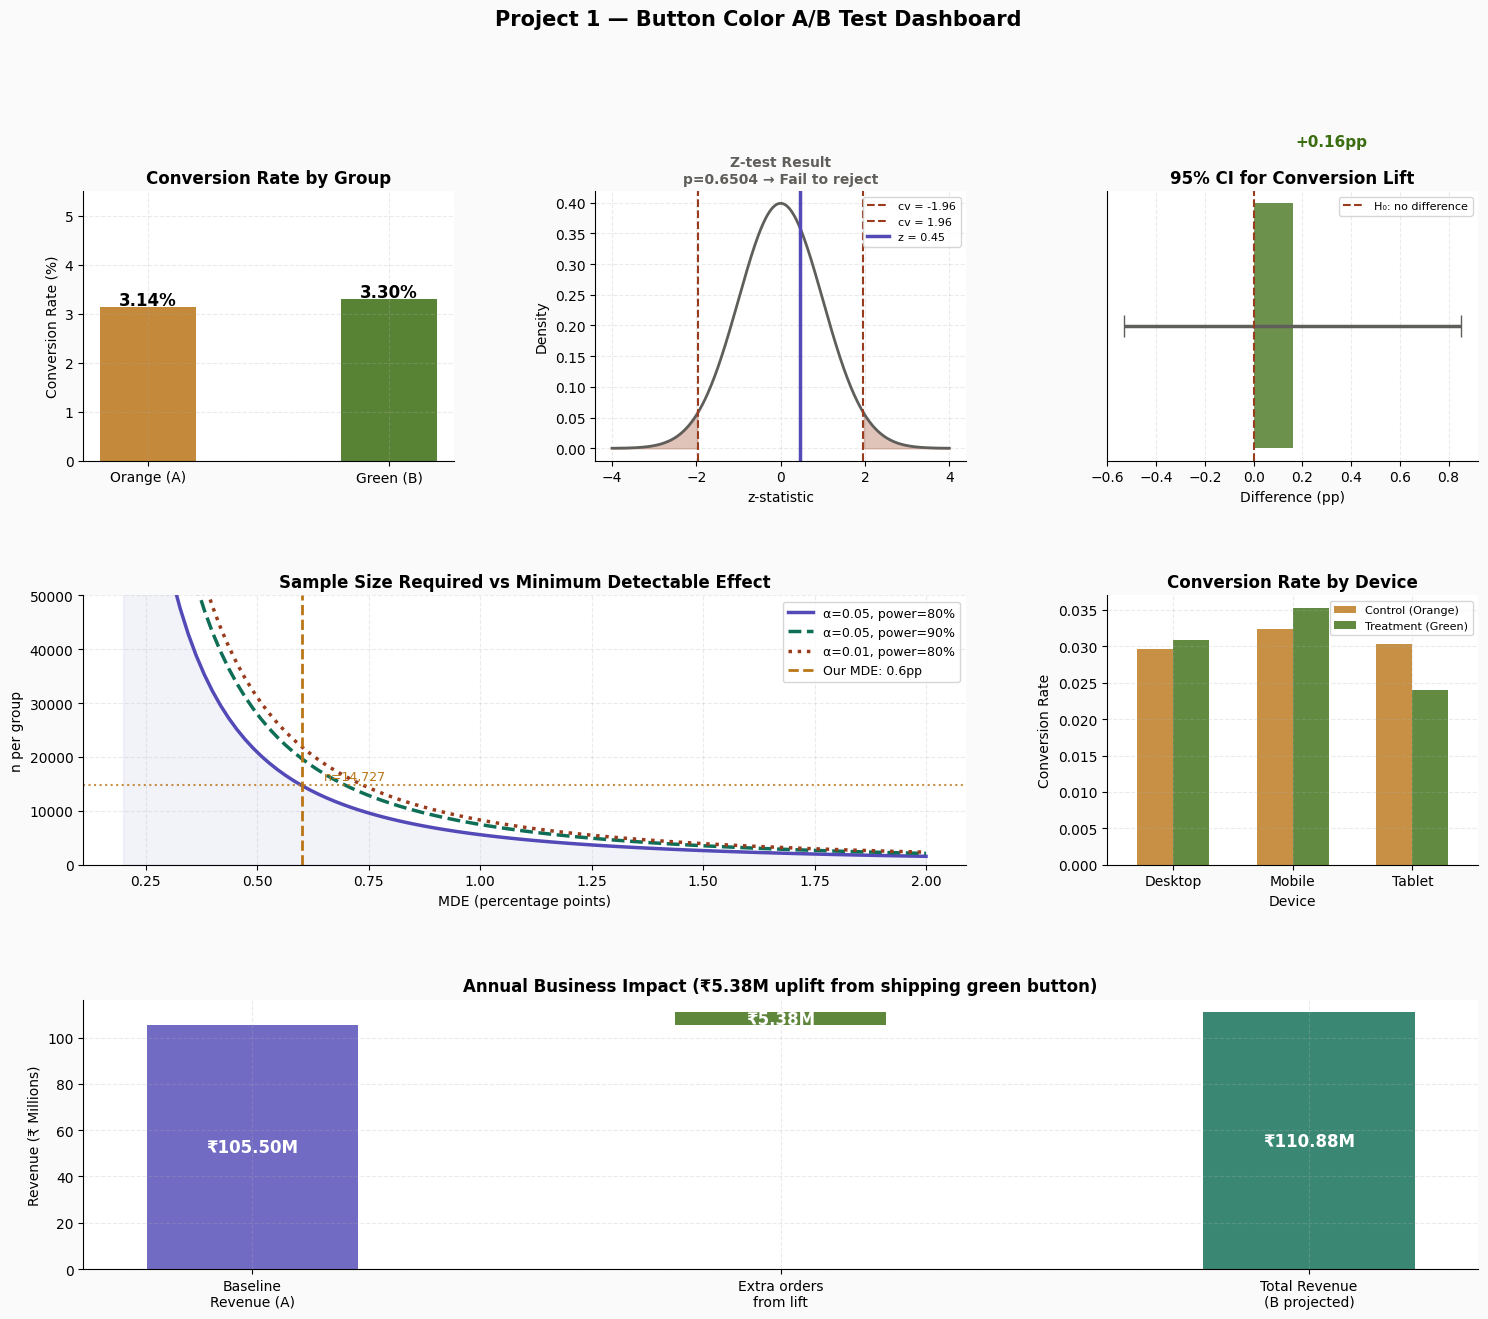

✅ Dashboard saved: p1_button_ab_test.png


In [ ]:
# ══ PHASE 6: FULL DASHBOARD ══
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Project 1 — Button Color A/B Test Dashboard', fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# P1: Conversion bars
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['Orange (A)','Green (B)'],
               [result_btn['p_A']*100, result_btn['p_B']*100],
               color=[AMBER, GREEN], alpha=0.85, width=0.4)
for bar, v in zip(bars, [result_btn['p_A'],result_btn['p_B']]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
             f'{v*100:.2f}%', ha='center', fontsize=12, fontweight='bold')
ax1.set_title('Conversion Rate by Group', fontweight='bold')
ax1.set_ylabel('Conversion Rate (%)'); ax1.set_ylim(0, 5.5)

# P2: Normal curve
# | Z Value | Decision        |
# | ------- | --------------- |
# | > 1.96  | Significant     |
# | < 1.96  | Not Significant |  0.45 < 1.96 - ❌ Significant இல்லை
# p-value - 0.6504 => 65% chance இந்த difference random-ஆ வந்திருக்கலாம்.
ax2 = fig.add_subplot(gs[0, 1])
plot_ab_curve(ax2, result_btn['z'], alpha=0.05, tail='two', title='Z-test Result')

# P3: CI plot
# Green Bar - +0.16pp - Observed Lift
# Horizontal Line - -0.53% to +0.85% = 95% Confidence Interval
# Red Dashed Line - 0% - No Difference
# CI line: -0.53% → +0.85% => 0-ஐ cross செய்கிறது. அதனால் ❌ Significant இல்லை.

ax3 = fig.add_subplot(gs[0, 2])
diff = (result_btn['p_B'] - result_btn['p_A'])*100
ci_lo = result_btn['ci'][0]*100; ci_hi = result_btn['ci'][1]*100
ax3.barh(0, diff, color=GREEN if diff>0 else CORAL, alpha=0.75, height=0.3)
ax3.errorbar(diff, 0, xerr=[[diff-ci_lo],[ci_hi-diff]],
             fmt='none', color=DGRAY, capsize=8, linewidth=2.5)
ax3.axvline(0, color=CORAL, linestyle='--', linewidth=1.5, label='H₀: no difference')
ax3.set_title('95% CI for Conversion Lift', fontweight='bold')
ax3.set_xlabel('Difference (pp)'); ax3.set_yticks([])
ax3.legend(fontsize=8)
ax3.text(diff+0.01, 0.22, f'{diff:+.2f}pp', color=GREEN, fontsize=11, fontweight='bold')

# P4: Sample size curve
# | MDE  | Sample Size |
# | ---- | ----------- |
# | 0.2% | Very High   |
# | 0.6% | 14,727      | users
# | 2.0% | Very Low    |
# Small improvements detect செய்ய More users தேவை.

ax4 = fig.add_subplot(gs[1, :2])
mde_range = np.linspace(0.002, 0.020, 100)
ns_80 = [calc_sample_size(p_baseline, m, alpha=0.05, power=0.80) for m in mde_range]
ns_90 = [calc_sample_size(p_baseline, m, alpha=0.05, power=0.90) for m in mde_range]
ns_95 = [calc_sample_size(p_baseline, m, alpha=0.01, power=0.80) for m in mde_range]
ax4.plot(mde_range*100, ns_80, color=PURPLE, linewidth=2.5, label='α=0.05, power=80%')
ax4.plot(mde_range*100, ns_90, color=TEAL,   linewidth=2.5, linestyle='--', label='α=0.05, power=90%')
ax4.plot(mde_range*100, ns_95, color=CORAL,  linewidth=2.5, linestyle=':', label='α=0.01, power=80%')
ax4.axvline(mde*100, color=AMBER, linewidth=2, linestyle='--', label=f'Our MDE: {mde*100:.1f}pp')
ax4.axhline(n_required, color=AMBER, linewidth=1.5, linestyle=':', alpha=0.8)
ax4.fill_between(mde_range*100, 0, ns_80, alpha=0.07, color=PURPLE)
ax4.set_title('Sample Size Required vs Minimum Detectable Effect', fontweight='bold')
ax4.set_xlabel('MDE (percentage points)'); ax4.set_ylabel('n per group')
ax4.set_ylim(0, 50000); ax4.legend(fontsize=9)
ax4.text(mde*100+0.05, n_required+1000, f'n={n_required:,}', color=AMBER, fontsize=9)

# P5: Conversion by device (segment analysis) - Button effect எல்லா devices-லயும் same இல்லை.
ax5 = fig.add_subplot(gs[1, 2])
seg = df_btn.groupby(['group','device'])['converted'].mean().unstack()
seg.T.plot(kind='bar', ax=ax5, color=[AMBER, GREEN], alpha=0.8, width=0.6)
ax5.set_title('Conversion Rate by Device', fontweight='bold')
ax5.set_xlabel('Device'); ax5.set_ylabel('Conversion Rate')
ax5.tick_params(axis='x', rotation=0); ax5.legend(fontsize=8)

# P6: Business impact waterfall
# | Question                  | Answer                  |
# | ------------------------- | ----------------------- |
# | Green conversion higher?  | ✅ Yes                   |
# | Lift?                     | +0.16 percentage points |
# | Relative lift?            | +5.1%                   |
# | Statistical significance? | ❌ No                    |
# | p-value                   | 0.6504                  |
# | CI includes 0?            | ✅ Yes                   |
# | Revenue gain possible?    | ₹5.38M/year             |
# | ROI                       | 27x                     |
# | Deploy immediately?       | ❌ No                    |
# | Recommendation            | Run experiment longer   |

ax6 = fig.add_subplot(gs[2, :])
categories = ['Baseline\nRevenue (A)', 'Extra orders\nfrom lift', 'Total Revenue\n(B projected)']
vals = [rev_A/1e6, uplift/1e6, rev_B/1e6]
bottoms = [0, rev_A/1e6, 0]
colors_wf = [PURPLE, GREEN, TEAL]
bars_wf = ax6.bar(categories, vals, bottom=bottoms, color=colors_wf, alpha=0.82, width=0.4)
for bar, v, b in zip(bars_wf, vals, bottoms):
    ax6.text(bar.get_x()+bar.get_width()/2, b+v/2,
             f'₹{v:.2f}M', ha='center', va='center',
             color='white', fontweight='bold', fontsize=12)
ax6.set_title(f'Annual Business Impact (₹{uplift/1e6:.2f}M uplift from shipping green button)',
              fontweight='bold')
ax6.set_ylabel('Revenue (₹ Millions)')

# Dashboard-ல் Green button conversion rate (3.30%) Orange button (3.14%) விட சிறிது அதிகமாக இருப்பது தெரிகிறது. 
# ஆனால் Z-test p-value 0.6504 மற்றும் confidence interval 0-ஐ உள்ளடக்கியதால் improvement statistically significant இல்லை. 
# Revenue uplift ₹5.38M மற்றும் ROI 27x என்றாலும், தற்போதைய data அடிப்படையில் Green button deploy செய்ய போதுமான evidence இல்லை. 
# எனவே experiment-ஐ மேலும் run செய்து அதிக sample சேகரிக்க வேண்டும். 🚀

plt.tight_layout()
plt.savefig('p1_button_ab_test.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved: p1_button_ab_test.png")

# | Panel  | Chart Name                | என்ன காட்டுகிறது?                | Business Meaning                         |
# | ------ | ------------------------- | -------------------------------- | ---------------------------------------- |
# | **P1** | Conversion Rate by Group  | Orange vs Green conversion rates | எந்த button அதிக conversion கொடுக்கிறது? |
# | **P2** | Z-Test Result             | Z-score மற்றும் rejection region | Difference statistically significant-ஆ?  |
# | **P3** | 95% Confidence Interval   | Conversion lift range            | Real improvement எவ்வளவு இருக்கலாம்?     |
# | **P4** | Sample Size vs MDE        | MDE மற்றும் required sample size | எவ்வளவு users தேவை?                      |
# | **P5** | Conversion by Device      | Mobile/Desktop/Tablet conversion | எந்த device-ல் அதிக conversion?          |
# | **P6** | Business Impact Waterfall | Revenue uplift                   | Deploy செய்தால் எவ்வளவு revenue?         |



---
---
# 💳 Project 2 — Pricing Page Layout Test
## Chi-Square Test for Categorical Outcomes

---

### Business Problem
A SaaS company tests two pricing page layouts. Visitors can: **Bounce**, choose **Free**, choose **Starter (₹499)**, or choose **Pro (₹999)**.  
The new layout emphasises the Pro plan more prominently.

> 📌 **Tamil:** "Chi-square test = categorical outcomes compare பண்ண use பண்றோம்.  
> Users எந்த plan select பண்றார்கள் — இது proportions மட்டும் இல்லை, multiple categories."

Proportions (ப்ரொபோர்ஷன்) Meaning: ஒரு குழுவில் ஒரு பகுதி எவ்வளவு சதவீதம் அல்லது விகிதம் உள்ளது என்பதைக் காட்டுவது.

Example: 100 users-ல்
40 பேர் Free plan எடுத்தால்
Proportion = 40/100 = 0.40 = 40%

👉 தமிழில்: விகிதம் / சதவீதப் பங்கு

### Why Chi-Square (not z-test)?
- Outcome has **4 categories** (Bounce / Free / Starter / Pro)
- We're testing whether the **distribution of choices** differs between groups
- Chi-square tests independence of two categorical variables

🎯 Why not Z-Test? - Z-test பொதுவாக:

✅ Yes / No

✅ Buy / Not Buy

✅ Click / No Click

மாதிரி 2 categories இருக்கும் போது use பண்ணுவோம்.

இங்க: Bounce, Free, Starter ,Pro என்று 4 categories இருக்கு. அதனால் Z-test use பண்ண முடியாது.
👉 Multiple categories compare செய்ய Chi-Square Test use பண்ண வேண்டும்.

---

Chi-Square Test = இரண்டு groups-ல உள்ள category distribution ஒரே மாதிரியா அல்லது வேற மாதிரியா இருக்கிறதா என்பதை கண்டுபிடிக்கும் test.

---

| Category    | Tamil Meaning                                                                  |
| ----------- | ------------------------------------------------------------------------------ |
| **Bounce**  | Website-க்கு வந்தவுடன் எந்த action-மும் செய்யாமல் வெளியேறுவது (விட்டு செல்வது) {40 பேர் → Bounce (எதுவும் செய்யாமல் வெளியேறினர்)}|
| **Free**    | இலவச (Free) திட்டத்தை தேர்வு செய்வது {35 பேர் → Free plan எடுத்தனர்}                                          |
| **Starter** | ஆரம்ப கட்ட கட்டண திட்டம் (₹499 Plan) தேர்வு செய்வது      {15 பேர் → Starter plan எடுத்தனர்}                      |
| **Pro**     | மேம்பட்ட/தொழில்முறை கட்டண திட்டம் (₹999 Plan) தேர்வு செய்வது    {10 பேர் → Pro plan எடுத்தனர்}            |



In [3]:
np.random.seed(77)
n_each = 3000

# Control: current pricing page
# Treatment: new layout emphasising Pro plan
probs_ctrl = [0.55, 0.25, 0.12, 0.08]   # Bounce,Free,Starter,Pro
probs_trt  = [0.50, 0.22, 0.11, 0.17]   # Treatment shifts users to Pro

plans = ['Bounce','Free','Starter (₹499)','Pro (₹999)']

choices_ctrl = np.random.choice(plans, n_each, p=probs_ctrl)
choices_trt  = np.random.choice(plans, n_each, p=probs_trt)

df_price = pd.DataFrame({
    'user_id' : [f'U{i:05d}' for i in range(1, n_each*2+1)],
    'group'   : ['Control']*n_each + ['Treatment']*n_each,
    'layout'  : ['Current']*n_each + ['New (Pro-featured)']*n_each,
    'plan_chosen': np.concatenate([choices_ctrl, choices_trt]),
    'country' : np.random.choice(['India','US','UK','Australia'],
                                  n_each*2, p=[0.50,0.25,0.15,0.10]),
})

df_price.to_csv('ab_pricing.csv', index=False)
print(f"✅ Dataset: ab_pricing.csv  ({len(df_price):,} rows × {df_price.shape[1]} cols)")
df_price.head(6)


✅ Dataset: ab_pricing.csv  (6,000 rows × 5 cols)


,user_id,group,layout,plan_chosen,country
0,U00001,Control,Current,Starter (₹499),US
1,U00002,Control,Current,Free,India
2,U00003,Control,Current,Free,India
3,U00004,Control,Current,Bounce,Australia
4,U00005,Control,Current,Bounce,India
5,U00006,Control,Current,Free,US


In [ ]:
# ── Contingency table ──Control group மற்றும் Treatment group-ல் எத்தனை பேர் எந்த plan தேர்வு செய்தார்கள் என்பதை count செய்கிறது.
ct = pd.crosstab(df_price['group'], df_price['plan_chosen'])
ct = ct[['Bounce','Free','Starter (₹499)','Pro (₹999)']]   # reorder
ct_pct = ct.div(ct.sum(axis=1), axis=0).round(4)

print("── Observed Counts ──") # ஒவ்வொரு group-ல் எத்தனை பேர் எந்த plan எடுத்தார்கள் என்பதை காட்டுகிறது.
print(ct.to_string()) 
print()
print("── Distribution (%) ──") # ஒவ்வொரு plan-க்கும் எவ்வளவு % users இருக்கிறார்கள் என்பதை காட்டுகிறது.
print((ct_pct*100).round(2).to_string()) # Percentage=(Count / Total Users) ​×100

# Revenue per user
rev_map = {'Bounce':0, 'Free':0, 'Starter (₹499)':499, 'Pro (₹999)':999}
rev_ctrl = sum(rev_map[p] for p in choices_ctrl)
rev_trt  = sum(rev_map[p] for p in choices_trt)
print(f"\n  Revenue per group:")
print(f"    Control  : ₹{rev_ctrl:,}  (avg ₹{rev_ctrl/n_each:.2f}/user)")
print(f"    Treatment: ₹{rev_trt:,}  (avg ₹{rev_trt/n_each:.2f}/user)")
print(f"    Lift     : ₹{rev_trt-rev_ctrl:,}  (+{(rev_trt-rev_ctrl)/rev_ctrl*100:.2f}%)")

# Revenue Per Group (வருவாய்)
# | Group     | Starter Revenue | Pro Revenue | Total Revenue | Avg Revenue / User |
# | --------- | --------------: | ----------: | ------------: | -----------------: |
# | Control   |        ₹181,636 |    ₹233,766 |      ₹415,402 |            ₹138.47 |
# | Treatment |        ₹154,191 |    ₹467,532 |      ₹621,723 |            ₹207.24 |

# Step 2: Difference ÷ Control Revenue => 415,402 / 206,321=0.4967
# Step 3: Convert to Percentage => 0.4967×10 =49.67%

# | Group         | Meaning (Tamil)                                                |
# | ------------- | -------------------------------------------------------------- |
# | **Control**   | பழைய Pricing Page (Old Layout) பார்த்த users                   |
# | **Treatment** | புதிய Pricing Page (New Layout) பார்த்த users                  |
# | **Purpose**   | New Layout நல்லதா கெட்டதா என்று Old Layout உடன் ஒப்பிட பார்க்க |


── Observed Counts ──
plan_chosen  Bounce  Free  Starter (₹499)  Pro (₹999)
group                                                
Control        1637   765             364         234
Treatment      1560   663             309         468

── Distribution (%) ──
plan_chosen  Bounce  Free  Starter (₹499)  Pro (₹999)
group                                                
Control       54.57  25.5           12.13         7.8
Treatment     52.00  22.1           10.30        15.6

  Revenue per group:
    Control  : ₹415,402  (avg ₹138.47/user)
    Treatment: ₹621,723  (avg ₹207.24/user)
    Lift     : ₹206,321  (+49.67%)


In [ ]:
# | Variable      | Meaning                                     |
# | ------------- | ------------------------------------------- |
# | chi2_stat     | Chi-Square Statistic                        |
# | p_chi2        | p-value                                     |
# | dof           | Degrees of Freedom                          |
# | expected_freq | H₀ உண்மையென்றால் எதிர்பார்க்கப்படும் counts |

# ── Chi-square test ───────────────────────────────────────────
chi2_stat, p_chi2, dof, expected_freq = chi2_contingency(ct)

print("══ CHI-SQUARE TEST OF INDEPENDENCE ══")
print()
print(f"  H₀: Plan choice distribution is independent of layout") # Old Layout, New Layout இரண்டிலும் users அதே மாதிரி plans தேர்வு செய்கிறார்கள்.
print(f"  H₁: Layout affects which plan users choose") # New Layout காரணமாக users வேறு plans தேர்வு செய்கிறார்கள்.
print()
print(f"  χ² statistic : {chi2_stat:.4f}")
print(f"  Degrees of freedom: {dof}  (rows-1)×(cols-1) = 1×3")
print(f"  p-value      : {p_chi2:.6f}")
# | p-value | Decision          |
# | ------- | ----------------- |
# | < 0.05  | Reject H₀         |
# | ≥ 0.05  | Fail to Reject H₀ |

print(f"  Critical value (α=0.05, df={dof}): {stats.chi2.ppf(0.95, df=dof):.4f}")
print()
# | Condition           | Decision  |
# | ------------------- | --------- |
# | χ² > Critical Value | Reject H₀ |
# | χ² ≤ Critical Value | Fail      |

print(f"  Decision: {'✅ REJECT H₀ — Layout significantly affects plan choice' if p_chi2<0.05 else '❌ Fail to reject H₀'}")
print()
print("── Expected Frequencies (under H₀) ──")
exp_df = pd.DataFrame(expected_freq, index=ct.index, columns=ct.columns).round(1)
print(exp_df.to_string())
print()
print("  ✓ All expected frequencies > 5 → chi-square valid")
print()

# Cramér's V (effect size) - Effect Size Difference இருக்கிறது என்று தெரியும். ஆனால் எவ்வளவு பெரிய difference? அதை அளக்கும் metric.
# | Cramér's V | Meaning |
# | ---------- | ------- |
# | <0.10      | Small   |
# | 0.10–0.30  | Medium  |
# | >0.30      | Large   |

n_total = ct.values.sum()
cramers_v = np.sqrt(chi2_stat / (n_total * min(ct.shape[0]-1, ct.shape[1]-1)))
print(f"  Effect size (Cramér's V): {cramers_v:.4f}")
print(f"  Interpretation: {'small' if cramers_v<0.1 else 'medium' if cramers_v<0.3 else 'large'} effect")

# | Metric             | Meaning (Tamil)                           |
# | ------------------ | ----------------------------------------- |
# | H₀                 | Layout impact இல்லை                       |
# | H₁                 | Layout impact இருக்கிறது                  |
# | χ² Statistic       | Observed vs Expected difference அளவு      |
# | Degrees of Freedom | (Rows−1)×(Cols−1)                         |
# | p-value            | இந்த result chance-ஆக வந்திருக்க வாய்ப்பு |
# | Critical Value     | Significant cutoff                        |
# | Expected Frequency | H₀ உண்மையானால் வர வேண்டிய count           |
# | Cramér's V         | Effect size (தாக்கத்தின் அளவு)            |

# 3️⃣ Degrees of Freedom = 3
# Formula:
# (rows−1)×(cols−1)
# (2−1)×(4−1)
# 1×3=3
# Tamil
# 2 Groups (Control, Treatment)
# 4 Plans (Bounce, Free, Starter, Pro)
# இருப்பதால் df = 3.

# | Metric         |   Value |
# | -------------- | ------: |
# | χ² Statistic   | 91.6351 |
# | Critical Value |  7.8147 |
# 91.6351>7.8147 ✅ H₀ Reject - χ² value cutoff-ஐ விட பல மடங்கு பெரியதாக உள்ளது.

# Expected Frequencies
# | Plan    | Control Actual | Control Expected |
# | ------- | -------------: | ---------------: |
# | Bounce  |           1637 |           1598.5 |
# | Free    |            765 |            714.0 |
# | Starter |            364 |            336.5 |
# | Pro     |            234 |            351.0 |


# χ² = 91.64 எப்படி வந்தது => χ2 =∑ (Observed−Expected)2 / Expected

# | Group     | Plan    | Observed (O) | Expected (E) |
# | --------- | ------- | -----------: | -----------: |
# | Control   | Bounce  |         1637 |       1598.5 |
# | Control   | Free    |          765 |        714.0 |
# | Control   | Starter |          364 |        336.5 |
# | Control   | Pro     |          234 |        351.0 |
# | Treatment | Bounce  |         1560 |       1598.5 |
# | Treatment | Free    |          663 |        714.0 |
# | Treatment | Starter |          309 |        336.5 |
# | Treatment | Pro     |          468 |        351.0 |

# | Cell              | Contribution |
# | ----------------- | -----------: |
# | Control Bounce    |         0.93 |
# | Control Free      |         3.64 |
# | Control Starter   |         2.25 |
# | Control Pro       |        39.00 |
# | Treatment Bounce  |         0.93 |
# | Treatment Free    |         3.64 |
# | Treatment Starter |         2.25 |
# | Treatment Pro     |        39.00 |
# | **Total χ²**      |    **91.64** |


# | Cell                   |      Expected Count | Rule Check (>5?) | Status               | Why Important?                                                                                           |
# | ---------------------- | ------------------: | ---------------- | -------------------- | -------------------------------------------------------------------------------------------------------- |
# | Control - Bounce       |              1598.5 | ✅ Yes            | Valid                | Expected count 5-ஐ விட அதிகம், Chi-Square approximation நன்றாக வேலை செய்யும்                             |
# | Control - Free         |               714.0 | ✅ Yes            | Valid                | p-value நம்பகமானதாக இருக்கும்                                                                            |
# | Control - Starter      |               336.5 | ✅ Yes            | Valid                | Statistical assumption satisfied                                                                         |
# | Control - Pro          |               351.0 | ✅ Yes            | Valid                | Result reliable                                                                                          |
# | Treatment - Bounce     |              1598.5 | ✅ Yes            | Valid                | Sample size போதுமானது                                                                                    |
# | Treatment - Free       |               714.0 | ✅ Yes            | Valid                | Approximation accurate                                                                                   |
# | Treatment - Starter    |               336.5 | ✅ Yes            | Valid                | Test assumption satisfied                                                                                |
# | Treatment - Pro        |               351.0 | ✅ Yes            | Valid                | Reliable inference                                                                                       |
# | **Overall Conclusion** | **Minimum = 336.5** | **✅ All > 5**    | **Chi-Square Valid** | **எல்லா Expected Counts-மும் 5-ஐ விட அதிகமாக இருப்பதால் Chi-Square test valid மற்றும் p-value reliable** |

# Chi-Square Test ஒரு approximation (தோராயமான கணித முறை).  அதற்காக statisticians ஒரு rule வைத்துள்ளனர்: Expected Frequency≥5
# | Expected Count Range | Interpretation                   |
# | -------------------: | -------------------------------- |
# |                  < 1 | ❌ Chi-Square பயன்படுத்தக்கூடாது  |
# |                1 – 5 | ⚠️ Result நம்பகத்தன்மை குறையலாம் |
# |                  > 5 | ✅ Chi-Square Valid               |
# |                 > 30 | ✅ மிகவும் நல்லது                 |
# |                > 100 | ✅ Excellent (உங்கள் case)        |


══ CHI-SQUARE TEST OF INDEPENDENCE ══

  H₀: Plan choice distribution is independent of layout
  H₁: Layout affects which plan users choose

  χ² statistic : 91.6351
  Degrees of freedom: 3  (rows-1)×(cols-1) = 1×3
  p-value      : 0.000000
  Critical value (α=0.05, df=3): 7.8147

  Decision: ✅ REJECT H₀ — Layout significantly affects plan choice

── Expected Frequencies (under H₀) ──
plan_chosen  Bounce   Free  Starter (₹499)  Pro (₹999)
group                                                 
Control      1598.5  714.0           336.5       351.0
Treatment    1598.5  714.0           336.5       351.0

  ✓ All expected frequencies > 5 → chi-square valid

  Effect size (Cramér's V): 0.1236
  Interpretation: medium effect


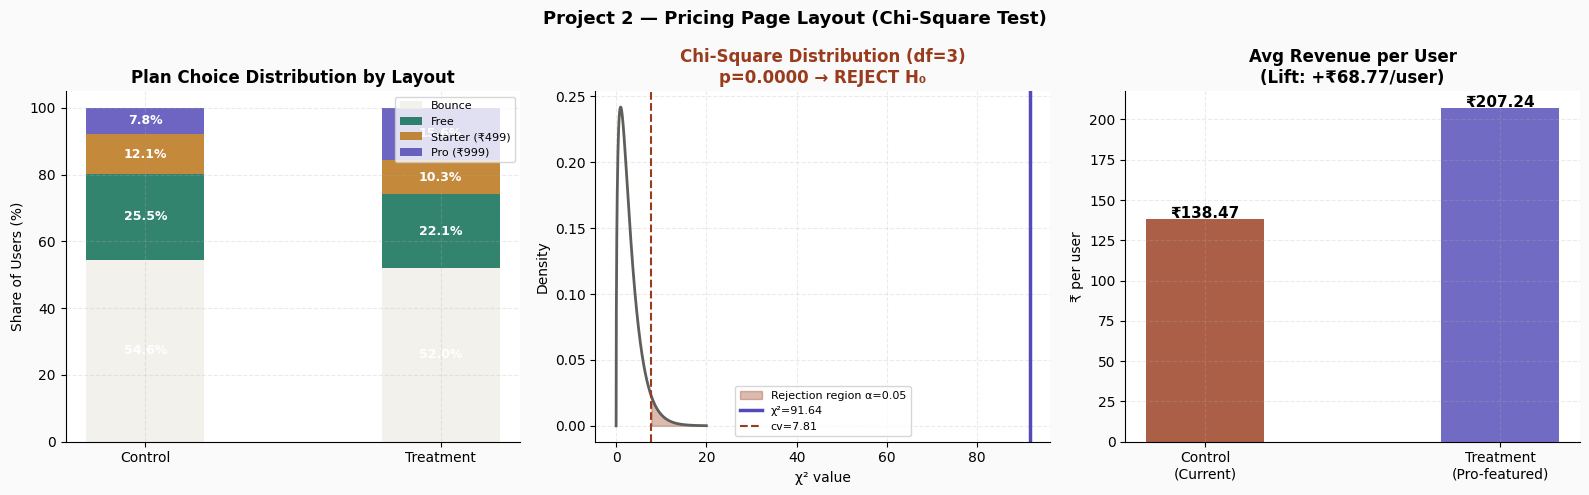

✅ Dashboard saved: p2_pricing_ab.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Project 2 — Pricing Page Layout (Chi-Square Test)', fontsize=13, fontweight='bold')

# 1. Stacked bar - Control (Old Layout) மற்றும் Treatment (New Layout) users எந்த plan தேர்வு செய்தார்கள் என்பதை % ஆக காட்டுகிறது.
# | Plan    | Control | Treatment |
# | ------- | ------: | --------: |
# | Bounce  |   54.6% |     52.0% |
# | Free    |   25.5% |     22.1% |
# | Starter |   12.1% |     10.3% |
# | Pro     |    7.8% |     15.6% |

ct_pct_plot = ct_pct.T
colors_plan = [LGRAY, TEAL, AMBER, PURPLE]
bottom = np.zeros(2)
for (plan, row), col in zip(ct_pct_plot.iterrows(), colors_plan):
    axes[0].bar(['Control','Treatment'], row.values*100,
                bottom=bottom, color=col, alpha=0.85, label=plan, width=0.4)
    for i, (v, b) in enumerate(zip(row.values*100, bottom)):
        if v > 3:
            axes[0].text(i, b+v/2, f'{v:.1f}%', ha='center', va='center',
                         color='white', fontsize=9, fontweight='bold')
    bottom += row.values*100
axes[0].set_title('Plan Choice Distribution by Layout', fontweight='bold')
axes[0].set_ylabel('Share of Users (%)'); axes[0].legend(fontsize=8, loc='upper right')

# 2. Chi-square distribution - இந்த chart statistical significance-ஐ காட்டுகிறது.
x_chi = np.linspace(0, 20, 400)
axes[1].plot(x_chi, stats.chi2.pdf(x_chi, df=dof), color=DGRAY, linewidth=2)
cv_chi = stats.chi2.ppf(0.95, df=dof)
xf = x_chi[x_chi >= cv_chi]
axes[1].fill_between(xf, 0, stats.chi2.pdf(xf, df=dof),
                      color=CORAL, alpha=0.35, label=f'Rejection region α=0.05')
axes[1].axvline(chi2_stat, color=PURPLE, linewidth=2.5, label=f'χ²={chi2_stat:.2f}')
axes[1].axvline(cv_chi, color=CORAL, linewidth=1.5, linestyle='--',
                label=f'cv={cv_chi:.2f}')
axes[1].set_title(f'Chi-Square Distribution (df={dof})\np={p_chi2:.4f} → REJECT H₀',
                   fontweight='bold', color=CORAL)
axes[1].set_xlabel('χ² value'); axes[1].set_ylabel('Density'); axes[1].legend(fontsize=8)

# 3. Revenue comparison
axes[2].bar(['Control\n(Current)','Treatment\n(Pro-featured)'],
            [rev_ctrl/n_each, rev_trt/n_each],
            color=[CORAL, PURPLE], alpha=0.82, width=0.4)
axes[2].set_title(f'Avg Revenue per User\n(Lift: +₹{(rev_trt-rev_ctrl)/n_each:.2f}/user)', fontweight='bold')
axes[2].set_ylabel('₹ per user')
axes[2].text(0, rev_ctrl/n_each+0.5, f'₹{rev_ctrl/n_each:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[2].text(1, rev_trt/n_each+0.5, f'₹{rev_trt/n_each:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('p2_pricing_ab.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved: p2_pricing_ab.png")

# chart:1 -  பழைய layout-ல் பல users Bounce/Free தேர்வு செய்தார்கள். புதிய layout-ல் Pro plan அதிகமாக highlight செய்யப்பட்டதால் Pro plan தேர்வு 7.8% → 15.6% ஆக இரட்டிப்பானது.
# 👉 "Users அதிகமாக Pro plan-க்கு மாறினர்."

# chart: 2 - இந்த மாற்றம் சும்மா luck காரணமாக வரவில்லை. χ² = 91.64 என்பது Critical Value 7.81-ஐ விட மிகவும் பெரியது, p-value ≈ 0.
# 👉 "Layout மாற்றம் உண்மையாகவே users-ன் plan choice-ஐ பாதித்துள்ளது."

# Pro plan அதிகமாக தேர்வு செய்யப்பட்டதால் revenue உயர்ந்தது.

# ₹138.47 → ₹207.24 ஒரு user-லிருந்து ₹68.77 கூடுதல் revenue கிடைத்தது.
# 👉 "புதிய layout business-க்கு அதிக பணம் சம்பாதித்துத் தந்தது."

---
---
# 📧 Project 3 — Email Subject Line A/B Test
## Open Rate Optimisation + Sequential Testing

---

### Business Problem
An e-commerce brand sends a promotional email to 20,000 subscribers.  
Two subject lines are tested to see which drives more opens.

- **A (Control):** "Your exclusive offer is waiting 🎁"
- **B (Treatment):** "Flash sale: 40% off ends tonight"

> 📌 **Tamil:** "Email subject line எது more opens கொண்டு வருகிறது?  
> Sequential testing — daily check பண்றோம், ஆனால் early stopping வேண்டாம்."

### Key Learning: Sequential Testing & Peeking Problem
Running the test and checking results every day can inflate false positives — called the **peeking problem**.


| Concept                     | Explanation (Tamil)                                                  | Example in Project                   |
| --------------------------- | -------------------------------------------------------------------- | ------------------------------------ |
| Business Problem            | எந்த email subject line அதிக opens தருகிறது என்பதை கண்டுபிடித்தல்    | Subject A vs Subject B               |
| Control                     | தற்போதைய / பழைய subject line                                         | "Your exclusive offer is waiting 🎁" |
| Treatment                   | புதிய subject line                                                   | "Flash sale: 40% off ends tonight"   |
| Subscriber Count            | Email அனுப்பப்பட்ட மொத்த மக்கள்                                      | 20,000 subscribers                   |
| Open Rate                   | Email open செய்தவர்களின் சதவீதம்                                     | Opens ÷ Emails Sent × 100            |
| Goal                        | Open Rate-ஐ அதிகரித்தல்                                              | அதிக opens பெறுதல்                   |
| A/B Test                    | இரண்டு versions compare செய்தல்                                      | Subject A vs Subject B               |
| Sequential Testing          | Test நடக்கும்போதே results check செய்தல்                              | Day 1, Day 2, Day 3...               |
| Peeking                     | அடிக்கடி result பார்ப்பது                                            | Daily p-value check                  |
| Peeking Problem             | அடிக்கடி பார்க்கும்போது false winner தேர்வு ஆகும் ஆபத்து             | Day 2 winner, Day 10 loser           |
| False Positive              | உண்மையில் difference இல்லாவிட்டும் difference உள்ளது என்று நினைத்தல் | Wrong winner declared                |
| H₀ (Null Hypothesis)        | Subject line open rate-ஐ பாதிக்கவில்லை                               | A மற்றும் B same open rate           |
| H₁ (Alternative Hypothesis) | Subject line open rate-ஐ பாதிக்கிறது                                 | A மற்றும் B different open rate      |
| Statistical Risk            | Early stopping காரணமாக தவறான decision                                | False Positive அதிகரிக்கும்          |
| Why Sequential Testing?     | Business விரைவாக முடிவு எடுக்க விரும்புகிறது                         | Daily monitoring                     |
| Main Challenge              | Peeking Problem                                                      | Frequent checking                    |
| Solution                    | Alpha Spending / Pocock / O'Brien-Fleming                            | False positive control               |
| Success Metric              | Open Rate                                                            | Email engagement                     |
| Business Outcome            | அதிக opens → அதிக clicks → அதிக sales                                | Better campaign performance          |



In [ ]:
np.random.seed(55)
n_total  = 20000
n_per    = n_total // 2

# True open rates
p_A_email = 0.218   # 21.8% open rate (control)
p_B_email = 0.247   # 24.7% open rate (treatment)

opens_A = np.random.binomial(1, p_A_email, n_per)
opens_B = np.random.binomial(1, p_B_email, n_per)

# Simulate sends over 7 days (batch delivery)
days_A = np.random.choice(range(1,8), n_per,
                           p=[0.05,0.08,0.20,0.30,0.20,0.10,0.07])
days_B = np.random.choice(range(1,8), n_per,
                           p=[0.05,0.08,0.20,0.30,0.20,0.10,0.07])

df_email = pd.DataFrame({
    'user_id'      : [f'U{i:06d}' for i in range(1, n_total+1)],
    'group'        : ['Control']*n_per + ['Treatment']*n_per,
    'subject_line' : ['Exclusive offer waiting']*n_per + ['Flash sale 40% off']*n_per,
    'opened'       : np.concatenate([opens_A, opens_B]),
    'day_of_send'  : np.concatenate([days_A, days_B]),
    'email_client' : np.random.choice(['Gmail','Outlook','Apple Mail','Other'],
                                       n_total, p=[0.42,0.27,0.20,0.11]),
    'subscriber_segment': np.random.choice(['New','Active','Lapsed'],
                                            n_total, p=[0.25,0.55,0.20]),
})

df_email.to_csv('ab_email.csv', index=False)
print(f"✅ Dataset: ab_email.csv  ({len(df_email):,} rows × {df_email.shape[1]} cols)")
df_email.head(6)

# | Column             | Type         | Example            | Meaning (Tamil)                        |
# | ------------------ | ------------ | ------------------ | -------------------------------------- |
# | user_id            | Categorical  | U000001            | ஒவ்வொரு subscriber-க்கும் unique ID    |
# | group              | Categorical  | Control, Treatment | User எந்த A/B test group-ல் உள்ளார்    |
# | subject_line       | Text         | Flash sale 40% off | User-க்கு அனுப்பப்பட்ட email subject   |
# | opened             | Binary (0/1) | 1                  | Email open செய்தாரா? (1=Yes, 0=No)     |
# | day_of_send        | Numerical    | 4                  | Email எந்த நாளில் அனுப்பப்பட்டது (1–7) |
# | email_client       | Categorical  | Gmail              | User எந்த email app பயன்படுத்துகிறார்  |
# | subscriber_segment | Categorical  | Active             | Subscriber வகை (New/Active/Lapsed)     |


✅ Dataset: ab_email.csv  (20,000 rows × 7 cols)


,user_id,group,subject_line,opened,day_of_send,email_client,subscriber_segment
0,U000001,Control,Exclusive offer waiting,0,4,Apple Mail,Lapsed
1,U000002,Control,Exclusive offer waiting,1,4,Gmail,Active
2,U000003,Control,Exclusive offer waiting,0,5,Gmail,Active
3,U000004,Control,Exclusive offer waiting,0,5,Gmail,New
4,U000005,Control,Exclusive offer waiting,0,3,Outlook,Active
5,U000006,Control,Exclusive offer waiting,0,5,Other,Active


In [ ]:
# Control (Current) = இப்போது பயன்படுத்தும் subject line.
# Treatment = புதிய subject line, இது better performance தருகிறதா என்று test செய்கிறோம்.

# | Variable | Source Feature | Meaning                                |
# | -------- | -------------- | -------------------------------------- |
# | opens_A  | opened         | Control users open செய்தார்களா (0/1)   |
# | opens_B  | opened         | Treatment users open செய்தார்களா (0/1) |
# | conv_A_e | sum(opened)    | Control total opens                    |
# | conv_B_e | sum(opened)    | Treatment total opens                  |

conv_A_e = opens_A.sum()
conv_B_e = opens_B.sum()
result_email = run_ab_test(conv_A_e, n_per, conv_B_e, n_per, alpha=0.05, tail='two')
print_result(result_email, 'Email Subject Line A/B Test')

print()
# Segment analysis — does the winner hold across segments? - lapsed means expiry 
print("── Segment Analysis (does winner hold across groups?) ──")
for seg in ['New','Active','Lapsed']:
    sub = df_email[df_email['subscriber_segment']==seg]
    c_A = sub[sub['group']=='Control']['opened'].sum()
    c_B = sub[sub['group']=='Treatment']['opened'].sum()
    n_s = sub[sub['group']=='Control'].shape[0]
    r   = run_ab_test(c_A, n_s, c_B, n_s)
    print(f"  {seg:8s}: A={c_A/n_s:.2%}  B={c_B/n_s:.2%}  "
          f"lift={r['lift']:+.2%}  p={r['p_val']:.4f}  "
          f"{'✅' if r['significant'] else '—'}")

# 1️⃣ Conversion A = 21.65% => Open Rate A= (Opens A / Emails Sent A)  ×100
# | Group   | Open Rate |
# | ------- | --------: |
# | Control |    21.65% | 100 emails அனுப்பினால்: சுமார் 22 பேர் open செய்கிறார்கள்.

# 3️⃣ Relative Lift = +15.89% => (25.09−21.65 / 21.65 ) ×100 =15.89%
# | Subject | Open Rate |
# | ------- | --------: |
# | A       |    21.65% |
# | B       |    25.09% | B subject line A-வை விட 15.89% அதிக opens பெற்றது. புதிய subject line open rate-ஐ 15.89% உயர்த்தியது.

# 4️⃣ Z-statistic = 5.7480
# | Z Value  | Meaning          |
# | -------- | ---------------- |
# | Around 0 | Difference இல்லை |
# | > 1.96   | Significant      |
# | < -1.96  | Significant      |
# | Z Value          | Meaning                                       |
# | ---------------- | --------------------------------------------- |
# | Z > 1.96         | ✅ Treatment significantly better than Control |
# | Z < -1.96        | ✅ Treatment significantly worse than Control  |
# | -1.96 ≤ Z ≤ 1.96 | ❌ Significant difference இல்லை                |

# 5.748>1.96 - Observed difference மிகவும் பெரியது. Control மற்றும் Treatment இடையே நல்ல அளவு வித்தியாசம் உள்ளது.

# 5️⃣ p-value = 0.0000 => H₀ உண்மையாக இருந்தால்
# இந்த result கிடைக்க வாய்ப்பு: ≈0%
# | p-value | Decision  |
# | ------- | --------- |
# | < 0.05  | Reject H₀ |
# | ≥ 0.05  | Fail      |
# Your Result : 0.0000<0.05 => ✅ Reject H₀ - இந்த improvement luck காரணமாக வரவில்லை.

# 6️⃣ Critical Value = ±1.96
# Meaning:  95% confidence-க்கு cutoff.
# | Condition | Result          |
# | --------- | --------------- |
# | Z > 1.96  | Significant     |
# | Z < -1.96 | Significant     |
# | Between   | Not Significant |

# | Metric   | Value |
# | -------- | ----: |
# | Z        | 5.748 |
# | Critical |  1.96 | 5.748>1.96 ✅ Significant

# 7️⃣ 95% Confidence Interval (2.268%,4.612%)
# Treatment open rate improvement:
# குறைந்தபட்சம் - +2.27%
# அதிகபட்சம் - +4.61% => இடையே இருக்கும். உண்மையான improvement 2.27% முதல் 4.61% வரை இருக்கலாம்.

# 8️⃣ Significant? = YES
# | Check          | Result |
# | -------------- | ------ |
# | p-value < 0.05 | ✅      |
# | Z > 1.96       | ✅      |
# | CI includes 0? | ❌ No   | அதனால்: ✅ Significant

# 9️⃣ Decision = SHIP ✅
# Business action: புதிய subject line-ஐ அனைத்து users-க்கும் பயன்படுத்தலாம்.
# Treatment subject line winner. Production-ல் deploy செய்யலாம்.

# | Segment | A Open Rate | B Open Rate | Lift Formula              |    Lift | p-value | Significant? | Interpretation            |
# | ------- | ----------: | ----------: | ------------------------- | ------: | ------: | ------------ | ------------------------- |
# | New     |      22.29% |      23.74% | ((23.74−22.29)/22.29)×100 |  +6.55% |  0.2235 | ❌ No         | Difference உறுதியாக இல்லை |
# | Active  |      21.76% |      25.83% | ((25.83−21.76)/21.76)×100 | +18.68% |  0.0000 | ✅ Yes        | Strong winner             |
# | Lapsed  |      20.54% |      24.70% | ((24.70−20.54)/20.54)×100 | +20.25% |  0.0018 | ✅ Yes        | Strong winner             |


════════════════════════════════════════════════════════════
  Email Subject Line A/B Test
════════════════════════════════════════════════════════════
  Conversion A  : 0.2165 = 21.65%
  Conversion B  : 0.2509 = 25.09%
  Relative lift : +15.89%
  Z-statistic   : 5.7480
  p-value       : 0.0000
  Critical value: ±1.9600
  95% CI (diff) : (2.268%, 4.612%)
  Significant?  : YES  (p < α)
  Decision      : SHIP ✅

── Segment Analysis (does winner hold across groups?) ──
  New     : A=22.29%  B=23.74%  lift=+6.55%  p=0.2235  —
  Active  : A=21.76%  B=25.83%  lift=+18.68%  p=0.0000  ✅
  Lapsed  : A=20.54%  B=24.70%  lift=+20.25%  p=0.0018  ✅


In [ ]:
# ── Sequential / Peeking Problem Visualisation ───────────────
# Shows how p-value fluctuates if you peek at results daily - 
# "Test முடிவதற்கு முன்பே தினமும் p-value பார்த்தால் என்ன பிரச்சனை வரும்?" என்பதை காட்டுகிறது.
print("── Peeking Problem Demonstration ──")
print("Checking p-value daily as emails are delivered:")
print()

daily_pvals = []
daily_ns    = []
for day in range(1, 8):
    mask_A = (df_email['group']=='Control') & (df_email['day_of_send']<=day)
    mask_B = (df_email['group']=='Treatment') & (df_email['day_of_send']<=day)
    cA_d = df_email[mask_A]['opened'].sum()
    cB_d = df_email[mask_B]['opened'].sum()
    nA_d = mask_A.sum(); nB_d = mask_B.sum()
    if nA_d > 50 and nB_d > 50:
        r_d  = run_ab_test(cA_d, nA_d, cB_d, nB_d)
        daily_pvals.append(r_d['p_val'])
        daily_ns.append(nA_d + nB_d)
        sig = '⚠️  Would have stopped early!' if r_d['p_val']<0.05 else '—'
        print(f"  Day {day}: n={nA_d+nB_d:,}  p={r_d['p_val']:.4f}  {sig}")

print()
print("  ► LESSON: p-value fluctuates during collection.")
print("    Never stop early based on peeking — wait for pre-planned n!")
print("    Use sequential testing methods (e.g. always-valid p-values) if early stopping is needed.")

# 0.05 = 5% => Convert to percentage: 0.05×100=5%
# | p-value | Percentage |
# | ------- | ---------- |
# | 0.3214  | 32.14%     |
# | 0.0143  | 1.43%      |

# | Percentage  | Result            |
# | ----------- | ----------------- |
# | 32.14% > 5% | ❌ Not Significant | 32.14 சதவீதம், 5 சதவீதத்தை விட அதிகம் → Significant இல்லை ❌ (Difference நம்பகமானது இல்லை)
# | 1.43% < 5%  | ✅ Significant     | 1.43 சதவீதம், 5 சதவீதத்தை விட குறைவு → Significant ✅ (Difference நம்பகமானது (Significant))

# | p-value | Size            | Meaning              |
# | ------- | --------------- | -------------------- |
# | 0.50    | Very Big        | No evidence          |
# | 0.32    | Big             | No evidence          |
# | 0.10    | Still Big       | No evidence          |
# | 0.049   | Small           | Significant          |
# | 0.014   | Very Small      | Significant          |
# | 0.001   | Extremely Small | Strong evidence      |
# | 0.0001  | Extremely Small | Very strong evidence |

# | Day     | Story                                                                  |
# | ------- | ---------------------------------------------------------------------- |
# | Day 1   | Data குறைவு, winner சொல்ல முடியாது                                     |
# | Day 2   | p-value 0.0143 வந்ததால் "Treatment winner!" என்று stop செய்திருக்கலாம் |
# | Day 3–7 | மேலும் data வந்த பிறகும் Treatment winner-ஆகவே இருந்தது                |
# | Final   | Day 7 result-ல் Treatment உண்மையான winner என்று உறுதி ஆனது             |

# ⚠️ Would have stopped early! :
# "Day 2-லேயே p < 0.05 வந்துவிட்டது. அதனால் test-ஐ அங்கேயே நிறுத்தி winner அறிவித்திருக்கலாம்."
# ஆனால் நல்ல practice: முன்கூட்டியே தீர்மானித்த sample size (20,000) வரை wait செய்ய வேண்டும்.

# Day 1-ல் evidence இல்லை; Day 2 முதல் p-value 0.05-ஐ விட குறைவாக வந்ததால் Treatment winner போல தெரிந்தது. 
# ஆனால் A/B Test-ஐ நடுவில் நிறுத்தாமல் Day 7 வரை காத்திருந்து final decision எடுக்க வேண்டும். 📊📧✅


── Peeking Problem Demonstration ──
Checking p-value daily as emails are delivered:

  Day 1: n=972  p=0.3214  —
  Day 2: n=2,640  p=0.0143  ⚠️  Would have stopped early!
  Day 3: n=6,675  p=0.0001  ⚠️  Would have stopped early!
  Day 4: n=12,654  p=0.0000  ⚠️  Would have stopped early!
  Day 5: n=16,673  p=0.0000  ⚠️  Would have stopped early!
  Day 6: n=18,646  p=0.0000  ⚠️  Would have stopped early!
  Day 7: n=20,000  p=0.0000  ⚠️  Would have stopped early!

  ► LESSON: p-value fluctuates during collection.
    Never stop early based on peeking — wait for pre-planned n!
    Use sequential testing methods (e.g. always-valid p-values) if early stopping is needed.


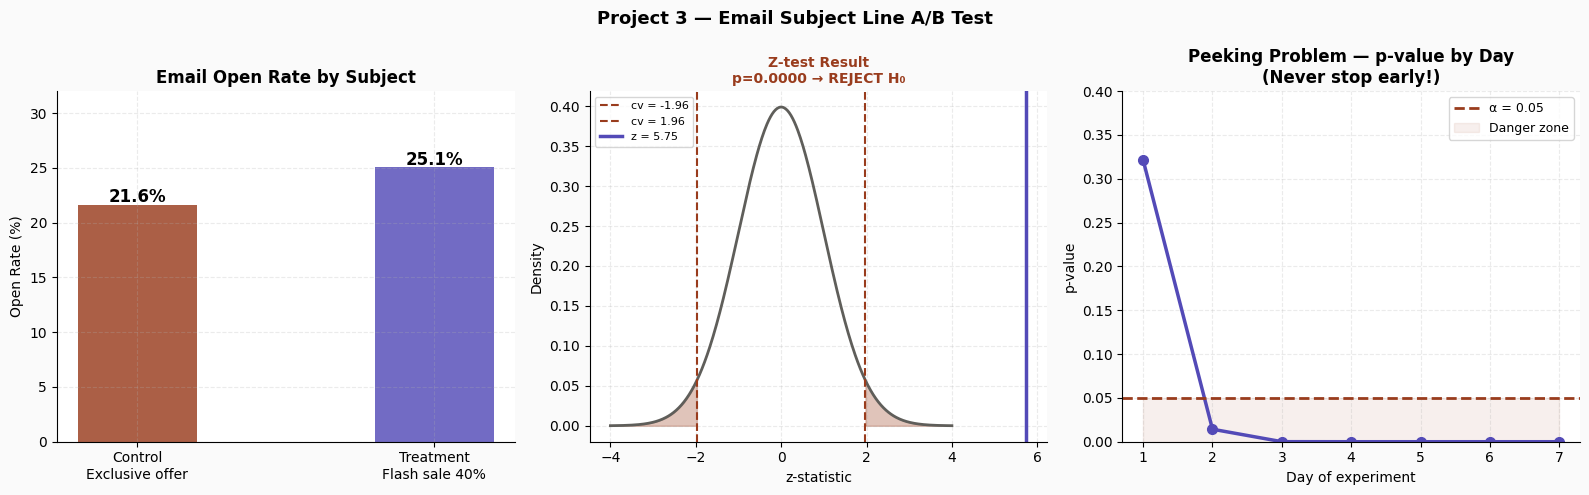

✅ Dashboard saved: p3_email_ab.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Project 3 — Email Subject Line A/B Test', fontsize=13, fontweight='bold')

# 1. Open rate comparison
groups = ['Control\nExclusive offer', 'Treatment\nFlash sale 40%']
rates  = [result_email['p_A']*100, result_email['p_B']*100]
bars = axes[0].bar(groups, rates, color=[CORAL, PURPLE], alpha=0.82, width=0.4)
for bar, v in zip(bars, rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Email Open Rate by Subject', fontweight='bold')
axes[0].set_ylabel('Open Rate (%)'); axes[0].set_ylim(0, 32)

# 2. Z-test result
# Blue line மிகவும் வலது பக்கம் இருக்கிறது.
# 👉 இந்த difference chance காரணமாக வரவில்லை. 👉 Treatment உண்மையாகவே better.
plot_ab_curve(axes[1], result_email['z'], alpha=0.05, tail='two', title='Z-test Result')

# 3. Peeking problem
if daily_pvals:
    axes[2].plot(range(1, len(daily_pvals)+1), daily_pvals,
                 color=PURPLE, linewidth=2.5, marker='o', markersize=7)
    axes[2].axhline(0.05, color=CORAL, linewidth=2, linestyle='--', label='α = 0.05')
    axes[2].fill_between(range(1, len(daily_pvals)+1), 0, 0.05,
                          alpha=0.08, color=CORAL, label='Danger zone')
    axes[2].set_title('Peeking Problem — p-value by Day\n(Never stop early!)', fontweight='bold')
    axes[2].set_xlabel('Day of experiment'); axes[2].set_ylabel('p-value')
    axes[2].legend(fontsize=9); axes[2].set_ylim(0, 0.4)

plt.tight_layout()
plt.savefig('p3_email_ab.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved: p3_email_ab.png")


---
---
# 🛒 Project 4 — Checkout Flow Simplification
## Statistical Power Analysis + Underpowered Test Warning

---

### Business Problem
Engineering simplified the checkout from 4 steps to 2 steps.  
The PM wants to test it. But they can only run it for 1 week (low sample size).

பழைய Checkout Process = 4 Steps, புதிய Checkout Process = 2 Steps
PM நினைப்பது: "Steps குறைந்ததால் users அதிகமாக purchase complete பண்ணுவார்கள்." இதைக் A/B Test மூலம் verify செய்ய வேண்டும்.

H₀ (Null Hypothesis) 2-step checkout எந்த மாற்றமும் செய்யவில்லை

H0 :pA=pB => A = Old Checkout, B = New Checkout

H₁ (Alternative Hypothesis) => 2-step checkout conversion increase செய்கிறது

H1 :pB>pA

> 📌 **Tamil:** "Statistical Power = real effect-ஐ detect பண்ண எவ்வளவு chance இருக்கிறது.  
> Sample size insufficient-ஆ இருந்தால், real effect-ஐ miss பண்ணிடுவோம் (Type II error)."

### Key Learning: Type I & Type II Errors
| | H₀ True (no effect) | H₀ False (real effect) |
|--|--|--|
| **Reject H₀** | Type I error (α) — false positive | Correct! |
| **Fail to reject** | Correct! | Type II error (β) — false negative |

| Reality        | Our Decision                    | Result          |
| -------------- | ------------------------------- | --------------- |
| Effect இல்லை   | Effect இருக்கு என்று சொல்கிறோம் | ❌ Type I Error  |
| Effect இல்லை   | Effect இல்லை என்று சொல்கிறோம்   | ✅ Correct       |
| Effect இருக்கு | Effect இருக்கு என்று சொல்கிறோம் | ✅ Correct       |
| Effect இருக்கு | Effect இல்லை என்று சொல்கிறோம்   | ❌ Type II Error |

---

| Concept           | Tamil                                                     |
| ----------------- | --------------------------------------------------------- |
| Type I Error (α)  | **இல்லாத effect-ஐ இருக்கிறது என்று நம்புவது**             |
| Type II Error (β) | **இருக்கும் effect-ஐ detect செய்யாமல் miss செய்வது**      |
| Statistical Power | **உண்மையான effect-ஐ கண்டுபிடிக்கும் திறன்**               |
| Underpowered Test | **Sample size குறைவால் real effect-ஐ miss செய்யும் test** |

---

| Concept            | Type I Error (α)                | Type II Error (β)                   | Statistical Power (1−β)                       |
| ------------------ | ------------------------------- | ----------------------------------- | --------------------------------------------- |
| Meaning            | False Positive                  | False Negative                      | Real effect-ஐ detect செய்யும் probability     |
| Reality            | Effect இல்லை                    | Effect இருக்கு                      | Effect இருக்கு                                |
| Decision           | Effect இருக்கு என்று சொல்கிறோம் | Effect இல்லை என்று சொல்கிறோம்       | Effect இருக்கு என்று சரியாக detect செய்கிறோம் |
| Checkout Example   | New checkout improve ஆகவில்லை   | New checkout improve ஆகியுள்ளது     | New checkout improve ஆகியதை கண்டுபிடிக்கிறோம் |
| Real Conversion    | Old=10%, New=10%                | Old=10%, New=12%                    | Old=10%, New=12%                              |
| Sample Result      | Old=10%, New=12%                | Old=10.1%, New=10.8%                | Old=10%, New=12.1%                            |
| p-value            | < 0.05                          | > 0.05                              | < 0.05                                        |
| Conclusion         | "New checkout works!"           | "No improvement"                    | "New checkout works!"                         |
| Result             | Wrong                           | Wrong                               | Correct                                       |
| Business Impact    | Bad feature deploy              | Good feature reject                 | Good feature deploy                           |
| Fire Alarm Example | 🔥 Fire இல்லை, Alarm அடிக்கிறது | 🔥 Fire இருக்கு, Alarm அடிக்கவில்லை | 🔥 Fire இருக்கு, Alarm அடிக்கிறது             |
| Goal               | α குறைக்க வேண்டும்              | β குறைக்க வேண்டும்                  | Power அதிகரிக்க வேண்டும்                      |



In [ ]:
# ஒரு E-commerce company-ல் Ravi என்ற PM இருக்கிறார். அவருடைய checkout process:
# | Stage   | Users Left |
# | ------- | ---------- |
# | Cart    | 1000       |
# | Address | 850        |
# | Payment | 740        |
# | Confirm | 680        | Final conversion 680 / 1000 = 68%
# மொத்தம் 4 steps. Ravi சொல்கிறார்: "இவ்வளவு steps இருப்பதால் users drop ஆகிறார்கள். 2 steps மட்டும் வைத்தால் conversion அதிகரிக்கும்."

# | Stage   | Users Left |
# | ------- | ---------- |
# | Cart    | 1000       |
# | Payment | 710        | Final conversion 710 / 1000 = 71% => 3 percentage points (pp) improvement


np.random.seed(2024)
# ஒரே 3% real improvement இருந்தாலும், sample size குறைவாக இருந்தால் test அதை detect செய்யாமல் miss செய்யலாம் (Type II Error).
# True effect: simplified checkout increases completion by 3pp= Percentage Points
p_A_chk = 0.68   # 68% checkout completion (current 4-step) Control (4-step)
p_B_chk = 0.71   # 71% checkout completion (new 2-step) Treatment (2-step)
true_mde = p_B_chk - p_A_chk # Difference

# Scenario 1: UNDERPOWERED (1 week, low traffic)
# What is Underpowered? Test-க்கு தேவையான sample size இல்லாத நிலை.
# Need = 3697 users/group, Got  = 400 users/group ஆனால் 400 users மட்டும் இருந்தால் random noise அதிகம்.
# Observed result: Control = 67%, Treatment = 69% அல்லது Control = 69%, Treatment = 70% Difference தெளிவாக தெரியாது

n_under = 400
conv_A_under = np.random.binomial(n_under, p_A_chk)
conv_B_under = np.random.binomial(n_under, p_B_chk)

# Scenario 2: PROPERLY POWERED (enough traffic)
# | Power | Sample Size     |
# | ----- | --------------- |
# | 80%   | ~3697/group     |
# | 90%   | More users      |
# | 95%   | Even more users |
# | 99%   | Huge users      |
# More power ⇒ More traffic ⇒ More time ⇒ More cost அதனால் industry standard:80%
n_proper = calc_sample_size(p_A_chk, true_mde, alpha=0.05, power=0.80) # 80%
conv_A_proper = np.random.binomial(n_proper, p_A_chk)
conv_B_proper = np.random.binomial(n_proper, p_B_chk)

# Build dataset (properly powered version)
df_chk = pd.DataFrame({
    'user_id'         : [f'U{i:05d}' for i in range(1, (n_proper*2)+1)],
    'group'           : ['Control']*n_proper + ['Treatment']*n_proper,
    'checkout_version': ['4-step']*n_proper + ['2-step']*n_proper,
    'completed'       : np.concatenate([
        np.random.binomial(1, p_A_chk, n_proper),
        np.random.binomial(1, p_B_chk, n_proper)
    ]),
    'cart_value_inr'  : np.random.lognormal(7.5, 0.6, n_proper*2).round(0),
    'device'          : np.random.choice(['Mobile','Desktop'],
                                          n_proper*2, p=[0.68, 0.32]),
})

df_chk.to_csv('ab_checkout.csv', index=False)
print(f"✅ Dataset: ab_checkout.csv  ({len(df_chk):,} rows × {df_chk.shape[1]} cols)")
print()

r_under  = run_ab_test(conv_A_under, n_under, conv_B_under, n_under)
r_proper = run_ab_test(conv_A_proper, n_proper, conv_B_proper, n_proper)

print("── Underpowered test (n=400 per group) ──")
print(f"   p-value: {r_under['p_val']:.4f}  → {r_under['decision']}")
print()
print(f"── Properly powered test (n={n_proper:,} per group) ──")
print(f"   p-value: {r_proper['p_val']:.4f}  → {r_proper['decision']}")
print()
print(f"  ► LESSON: Both test the SAME true effect (3pp lift).")
print(f"    Underpowered test misses it (Type II error / false negative).")
print(f"    You need n={n_proper:,}/group — not just 400!")

# | Item           | Underpowered  | Properly Powered |
# | -------------- | ------------- | ---------------- |
# | Users/group    | 400           | 3697             |
# | Noise          | High          | Low              |
# | Effect         | 3pp           | 3pp              |
# | p-value        | 0.323         | 0.003            |
# | Detect effect? | ❌ No          | ✅ Yes         |
# | Decision       | INCONCLUSIVE  | SHIP             |
# | Risk           | Type II Error | Low              |



✅ Dataset: ab_checkout.csv  (7,394 rows × 6 cols)

── Underpowered test (n=400 per group) ──
   p-value: 0.3230  → INCONCLUSIVE 🔄

── Properly powered test (n=3,697 per group) ──
   p-value: 0.0030  → SHIP ✅

  ► LESSON: Both test the SAME true effect (3pp lift).
    Underpowered test misses it (Type II error / false negative).
    You need n=3,697/group — not just 400!


In [ ]:
# ── Power Curve ───── Sample Size அதிகரித்தால் Power எப்படி அதிகரிக்கிறது?" என்பதை காட்டுகிறது.
# what is power Power = Real effect இருந்தால் அதை detect செய்யும் chance
print("── Statistical Power at Different Sample Sizes ──")
sample_sizes = [100, 200, 400, 800, 1200, n_proper, 3000, 5000] # ஒவ்வொரு sample size-க்கும் power calculate செய்கிறோம்.
for n_s in sample_sizes:
    # Analytical power formula
    z_alpha = norm.ppf(0.975) # two-tailed 95% confidence 95% confidence level. இதன் value:1.96 இதுதான் significance threshold.
    p_bar   = (p_A_chk + p_B_chk) / 2
    # SE = Standard Error "Random noise எவ்வளவு இருக்கிறது?"
    # "Random noise எவ்வளவு இருக்கிறது?" Sample size குறைந்தால்: Noise அதிகம் Sample size அதிகமானால்: Noise குறையும்
    se_h0   = np.sqrt(2 * p_bar * (1-p_bar) / n_s)
    se_h1   = np.sqrt(p_A_chk*(1-p_A_chk)/n_s + p_B_chk*(1-p_B_chk)/n_s)
    effect  = abs(p_B_chk - p_A_chk)
    z_power = (effect - z_alpha*se_h0) / se_h1
    power_n = norm.cdf(z_power) # இந்த sample size இருந்தால் effect detect ஆகும் probability
    marker = ' ← our underpowered n' if n_s==400 else (' ← required n' if n_s==n_proper else '')
    print(f"  n={n_s:>5,}: power = {power_n:.1%}{marker}")


── Statistical Power at Different Sample Sizes ──
  n=  100: power = 6.7%
  n=  200: power = 9.5%
  n=  400: power = 14.9% ← our underpowered n
  n=  800: power = 25.6%
  n=1,200: power = 35.8%
  n=3,697: power = 80.0% ← required n
  n=3,000: power = 71.4%
  n=5,000: power = 90.3%


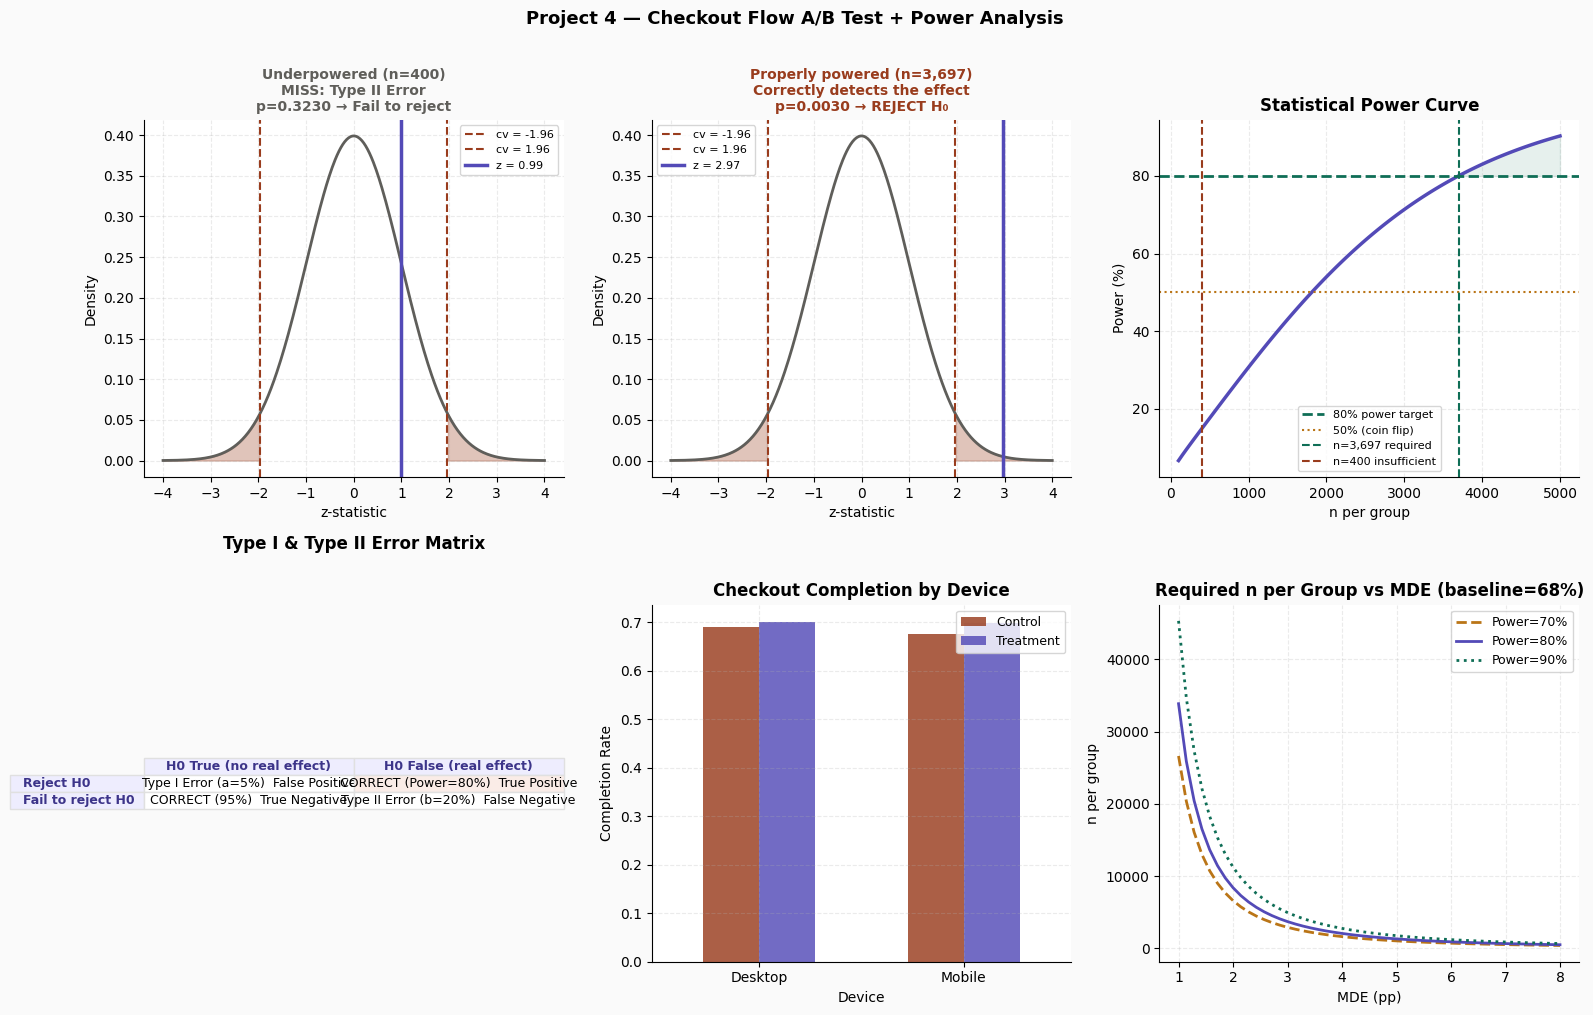

✅ Dashboard saved: p4_checkout_ab.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Project 4 — Checkout Flow A/B Test + Power Analysis', fontsize=13, fontweight='bold', y=1.01)

# P1: Underpowered result 
# நீல கோடு: -1.96 < 0.99 < 1.96 critical region-க்கு வெளியே போகவில்லை. 
# Fail to Reject H₀ அதாவது:"New checkout better என்று சொல்ல evidence இல்லை."
# Reality: 68% → 71% உண்மையில் improvement இருக்கு. ஆனால் n = 400 சிறிய sample size.
plot_ab_curve(axes[0,0], r_under['z'], alpha=0.05, tail='two',
              title=f'Underpowered (n={n_under})\nMISS: Type II Error')

# P2: Properly powered result - "New checkout statistically better."
plot_ab_curve(axes[0,1], r_proper['z'], alpha=0.05, tail='two',
              title=f'Properly powered (n={n_proper:,})\nCorrectly detects the effect')

# P3: Power curve
ns_range = np.arange(100, 5001, 50)
powers   = []
for n_s in ns_range:
    z_a  = norm.ppf(0.975)
    p_b  = (p_A_chk+p_B_chk)/2
    se0  = np.sqrt(2*p_b*(1-p_b)/n_s)
    se1  = np.sqrt(p_A_chk*(1-p_A_chk)/n_s + p_B_chk*(1-p_B_chk)/n_s)
    eff  = abs(p_B_chk-p_A_chk)
    powers.append(norm.cdf((eff - z_a*se0)/se1))

axes[0,2].plot(ns_range, [p*100 for p in powers], color=PURPLE, linewidth=2.5)
axes[0,2].axhline(80, color=TEAL,  linewidth=2, linestyle='--', label='80% power target')
axes[0,2].axhline(50, color=AMBER, linewidth=1.5, linestyle=':', label='50% (coin flip)')
axes[0,2].axvline(n_proper, color=TEAL, linewidth=1.5, linestyle='--',
                   label=f'n={n_proper:,} required')
axes[0,2].axvline(n_under, color=CORAL, linewidth=1.5, linestyle='--',
                   label=f'n={n_under} insufficient')
axes[0,2].fill_between(ns_range, [p*100 for p in powers], 80,
                        where=[p>=0.80 for p in powers], alpha=0.1, color=TEAL)
axes[0,2].set_title('Statistical Power Curve', fontweight='bold')
axes[0,2].set_xlabel('n per group'); axes[0,2].set_ylabel('Power (%)')
axes[0,2].legend(fontsize=8)

# P4: Error type matrix
axes[1,0].axis('off')
row_labels = ['Reject H0', 'Fail to reject H0']
col_labels = ['H0 True (no real effect)', 'H0 False (real effect)']
cell_vals  = [['Type I Error (a=5%)  False Positive', 'CORRECT (Power=80%)  True Positive'],
              ['CORRECT (95%)  True Negative',         'Type II Error (b=20%)  False Negative']]
tbl = axes[1,0].table(cellText=cell_vals,
                        rowLabels=row_labels,
                        colLabels=col_labels,
                        loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c),cell in tbl.get_celld().items():
    if (r==1 and c==1): cell.set_facecolor('#FAECE7')
    elif (r==2 and c==2): cell.set_facecolor('#FAECE7')
    elif r==0 or c==-1: cell.set_facecolor('#EEEDFE'); cell.set_text_props(fontweight='bold',color='#3C3489')
    cell.set_edgecolor('#E0E0E0')
axes[1,0].set_title('Type I & Type II Error Matrix', fontweight='bold', pad=40)

# P5: Completion by device
dev_seg = df_chk.groupby(['group','device'])['completed'].mean().unstack()
dev_seg.T.plot(kind='bar', ax=axes[1,1], color=[CORAL, PURPLE], alpha=0.82, width=0.55)
axes[1,1].set_title('Checkout Completion by Device', fontweight='bold')
axes[1,1].set_xlabel('Device'); axes[1,1].set_ylabel('Completion Rate')
axes[1,1].tick_params(axis='x', rotation=0); axes[1,1].legend(fontsize=9)

# P6: Sample size trade-off: alpha vs power vs n 👉 சின்ன effect detect செய்ய = பெரிய sample size தேவை 👉 பெரிய effect detect செய்ய = சின்ன sample size போதும்
# | Effect Size (MDE) | Required Sample |
# | ----------------- | --------------- |
# | 1pp               | Very High       |
# | 2pp               | High            |
# | 3pp               | ~3697           |
# | 5pp               | Medium          |
# | 8pp               | Low             |

ax6 = axes[1,2]
for pw, col, ls in [(0.70,AMBER,'--'),(0.80,PURPLE,'-'),(0.90,TEAL,':')]:
    ns_cfg = [calc_sample_size(p_A_chk, m, alpha=0.05, power=pw)
              for m in np.linspace(0.01, 0.08, 50)]
    ax6.plot(np.linspace(1,8,50), ns_cfg, color=col, linewidth=2,
             linestyle=ls, label=f'Power={int(pw*100)}%')
ax6.set_title('Required n per Group vs MDE (baseline=68%)', fontweight='bold')
ax6.set_xlabel('MDE (pp)'); ax6.set_ylabel('n per group')
ax6.legend(fontsize=9)

plt.tight_layout()
plt.savefig('p4_checkout_ab.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved: p4_checkout_ab.png")


---
---
# 🏠 Project 5 — Multi-Variant Homepage Test (A/B/C/D)
## Chi-Square + Post-Hoc Pairwise Tests with Bonferroni Correction

---

### Business Problem
The design team wants to test **4 homepage variants** simultaneously — one control + 3 treatments.

> 📌 **Tamil:** "Multiple variants test பண்ணும் போது, chi-square test overall significance காட்டுகிறது. At least one variant different ❌ எந்த pair different என்று தெரியாது

| Question                         | தமிழ்                                                  |
| -------------------------------- | ------------------------------------------------------ |
| What does Chi-Square test check? | 4 homepage variants-லும் ஏதாவது difference இருக்கிறதா? |
| H₀                               | எல்லா variants-மும் ஒரே conversion rate                |
| H₁                               | குறைந்தபட்சம் ஒரு variant வேறுபடுகிறது                 |
| p-value < 0.05                   | Significant Difference உள்ளது                          |
| p-value > 0.05                   | Difference இல்லை                                       |

---

> Post-hoc pairwise tests எந்த specific pair different என்று காட்டுகிறது.  

| Pair   | Meaning              |
| ------ | -------------------- |
| A vs B | Control vs Design B  |
| A vs C | Control vs Design C  |
| A vs D | Control vs Design D  |
| B vs C | Design B vs Design C |
| B vs D | Design B vs Design D |
| C vs D | Design C vs Design D |

---

> Bonferroni correction — multiple testing-இல் false positive rate control பண்றது."

| Pair   | p-value | Normal Rule (0.05) | Bonferroni (0.0083) |
| ------ | ------- | ------------------ | ------------------- |
| A vs B | 0.12    | ❌                  | ❌                   |
| A vs C | 0.001   | ✅                  | ✅                   |
| A vs D | 0.30    | ❌                  | ❌                   |
| B vs C | 0.006   | ✅                  | ✅                   |
| B vs D | 0.50    | ❌                  | ❌                   |
| C vs D | 0.04    | ✅                  | ❌                   |

---

### ⚠️ Multiple Testing Problem
Running 6 pairwise tests at α=0.05 each → probability of at least one false positive = 1−(0.95)⁶ = 26%!  
**Bonferroni correction:** (α / Number of Tests)use α/k for each test (α=0.05/6 = 0.0083)

multi-varient 
| Concept                     | English Meaning      | தமிழ் விளக்கம்                                       | Example          |
| --------------------------- | -------------------- | ---------------------------------------------------- | ---------------- |
| Control (A)                 | Original Homepage    | பழைய Homepage                                        | Variant A        |
| Treatment (B,C,D)           | New Homepage Designs | புதிய Homepage Designs                               | Variant B,C,D    |
| Multi-Variant Test          | A/B/C/D Test         | ஒரே நேரத்தில் பல versions test செய்வது               | A vs B vs C vs D |
| Conversion Rate             | Users Converted %    | Homepage பார்த்த பிறகு signup/purchase செய்தவர்கள் % | 10%, 12%, 15%    |
| Null Hypothesis (H₀)        | No Difference        | எல்லா homepage-களும் ஒரே performance                 | A=B=C=D          |
| Alternative Hypothesis (H₁) | Difference Exists    | குறைந்தபட்சம் ஒரு homepage வேறுபடுகிறது              | A≠C              |

---

| Topic                    | One-Line Tamil                                          |
| ------------------------ | ------------------------------------------------------- |
| Chi-Square Test          | 4 variants-லும் ஏதாவது difference இருக்கிறதா?           |
| Post-Hoc Test            | எந்த specific pair different?                           |
| Multiple Testing Problem | பல tests காரணமாக false positive அதிகரிக்கும்            |
| Bonferroni Correction    | False positive rate-ஐ control செய்ய α-வை divide செய்வது |
| α=0.05                   | 5% False Positive Risk                                  |
| α=0.0083                 | Bonferroni corrected threshold                          |
| Significant Pair         | p-value < 0.0083                                        |
| Non-Significant Pair     | p-value > 0.0083                                        |



In [7]:
np.random.seed(99)
n_var = 2500   # per variant

# True conversion rates for each homepage
true_rates = {
    'A_Control'  : 0.042,   # 4.2%
    'B_Hero_img' : 0.051,   # 5.1% — larger hero image
    'C_Social'   : 0.048,   # 4.8% — social proof section
    'D_Video'    : 0.063,   # 6.3% — video background (winner)
}

records_mv = []
for variant, p_true in true_rates.items():
    convs = np.random.binomial(1, p_true, n_var)
    for c in convs:
        records_mv.append({
            'user_id'  : f'U{len(records_mv)+1:06d}',
            'variant'  : variant,
            'converted': c,
            'device'   : np.random.choice(['Mobile','Desktop','Tablet'],
                                           p=[0.60,0.32,0.08]),
        })

df_mv = pd.DataFrame(records_mv)
df_mv.to_csv('ab_multivariant.csv', index=False)
print(f"✅ Dataset: ab_multivariant.csv  ({len(df_mv):,} rows × {df_mv.shape[1]} cols)")
df_mv.head(6)


✅ Dataset: ab_multivariant.csv  (10,000 rows × 4 cols)


,user_id,variant,converted,device
0,U000001,A_Control,0,Desktop
1,U000002,A_Control,0,Mobile
2,U000003,A_Control,0,Desktop
3,U000004,A_Control,0,Mobile
4,U000005,A_Control,0,Mobile
5,U000006,A_Control,0,Desktop


In [ ]:
# ── Overall chi-square first ──────────────────────────────────
ct_mv = pd.crosstab(df_mv['variant'], df_mv['converted'])
ct_mv.columns = ['Not converted','Converted']
print("── Observed Counts ──")
print(ct_mv)
print()

chi2_mv, p_mv, dof_mv, _ = chi2_contingency(ct_mv)
print(f"  Overall chi-square test: χ²={chi2_mv:.4f}  df={dof_mv}  p={p_mv:.6f}")
print(f"  Decision: {'✅ At least one variant differs significantly' if p_mv<0.05 else '❌ No significant differences'}")
print()

# Conversion rates summary  Conversion Rate = Conversions ÷ Total Users => 113/2500 = 0.0452  => 0.0452 x 100 = 4.52%
print("── Conversion Rate by Variant ──")
conv_rates = df_mv.groupby('variant')['converted'].agg(['sum','count','mean'])
conv_rates.columns = ['Conversions','Total','Rate']
conv_rates['Rate_pct'] = (conv_rates['Rate']*100).round(2)
conv_rates = conv_rates.sort_values('Rate', ascending=False)
print(conv_rates.to_string())

# | Question                | Answer                               |
# | ----------------------- | ------------------------------------ |
# | Are all variants same?  | ❌ No                                 |
# | Chi-Square Significant? | ✅ Yes                                |
# | p-value                 | 0.000007                             |
# | Best Variant            | 🏆 D_Video                           |
# | Worst Variant           | A_Control                            |
# | Highest Conversion      | 7.44%                                |
# | Lowest Conversion       | 4.52%                                |
# | Next Step               | Pairwise Post-Hoc Tests + Bonferroni |

# | Term              | Meaning                                                     | Example                                 |
# | ----------------- | ----------------------------------------------------------- | --------------------------------------- |
# | **Converted** =1    | Website-க்கு வந்த user, நாம் எதிர்பார்த்த action-ஐ செய்தார் | Signup செய்தார், Product வாங்கினார்     |
# | **Not Converted** = 0 | Website-க்கு வந்த user, action செய்யாமல் வெளியேறினார்       | Signup செய்யவில்லை, Product வாங்கவில்லை |



── Observed Counts ──
            Not converted  Converted
variant                             
A_Control            2387        113
B_Hero_img           2376        124
C_Social             2380        120
D_Video              2314        186

  Overall chi-square test: χ²=26.7081  df=3  p=0.000007
  Decision: ✅ At least one variant differs significantly

── Conversion Rate by Variant ──
            Conversions  Total    Rate  Rate_pct
variant                                         
D_Video             186   2500  0.0744      7.44
B_Hero_img          124   2500  0.0496      4.96
C_Social            120   2500  0.0480      4.80
A_Control           113   2500  0.0452      4.52


In [ ]:
# ── Pairwise post-hoc tests with Bonferroni correction ────────
from itertools import combinations

variants = list(true_rates.keys())
pairs    = list(combinations(variants, 2))
k        = len(pairs) # k = Total Number of Pairwise Tests
alpha_bonf = 0.05 / k   # Bonferroni-corrected threshold

print(f"── Pairwise Z-tests (Bonferroni α = 0.05/{k} = {alpha_bonf:.4f}) ──")
print()
print(f"  {'Pair':<40} {'z':>7} {'p':>8} {'adj-p':>8} {'Sig (Bonf)':>12}")
print("  " + "─"*77)

posthoc_results = []
for v1, v2 in pairs:
    g1 = df_mv[df_mv['variant']==v1]
    g2 = df_mv[df_mv['variant']==v2]
    c1 = g1['converted'].sum(); n1 = len(g1)
    c2 = g2['converted'].sum(); n2 = len(g2)
    r  = run_ab_test(c1, n1, c2, n2, alpha=alpha_bonf)
    adj_p = min(r['p_val'] * k, 1.0)   # Bonferroni-adjusted p-value
    sig   = adj_p < 0.05
    posthoc_results.append({
        'pair':f'{v1} vs {v2}','z':r['z'],'p':r['p_val'],
        'adj_p':adj_p,'significant':sig,
        'winner':v1 if r['p_A']>r['p_B'] else v2
    })
    print(f"  {v1+' vs '+v2:<40} {r['z']:>7.3f} {r['p_val']:>8.4f} {adj_p:>8.4f} {'✅ YES' if sig else '—':>12}")

print()
ph_df = pd.DataFrame(posthoc_results)
sig_pairs = ph_df[ph_df['significant']]
print(f"  Significant pairs after Bonferroni: {len(sig_pairs)}/{k}")
if len(sig_pairs):
    print("  " + ", ".join(sig_pairs['pair'].tolist()))

# | Pair   | Compared Variants       | Conversion Rate | z-value | p-value | adj-p (Bonferroni) | Sig?  | Tamil Meaning                                        |
# | ------ | ----------------------- | --------------- | ------: | ------: | -----------------: | ----- | ---------------------------------------------------- |
# | A vs B | A_Control vs B_Hero_img | 4.52% vs 4.96%  |   0.732 |  0.4641 | adj_p = p * k  1.0000 | ❌ No  | B கொஞ்சம் அதிகம், ஆனால் statistical difference இல்லை |
# | A vs C | A_Control vs C_Social   | 4.52% vs 4.80%  |   0.470 |  0.6386 |             1.0000 | ❌ No  | A மற்றும் C கிட்டத்தட்ட same performance             |
# | A vs D | A_Control vs D_Video    | 4.52% vs 7.44%  |   4.354 |  0.0000 |             0.0001 | ✅ Yes | D, A-வை விட மிகச் சிறந்தது                           |
# | B vs C | B_Hero_img vs C_Social  | 4.96% vs 4.80%  |  -0.263 |  0.7929 |             1.0000 | ❌ No  | B மற்றும் C ஒரே மாதிரி                               |
# | B vs D | B_Hero_img vs D_Video   | 4.96% vs 7.44%  |   3.636 |  0.0003 |             0.0017 | ✅ Yes | D, B-வை விட சிறந்தது                                 |
# | C vs D | C_Social vs D_Video     | 4.80% vs 7.44%  |   3.894 |  0.0001 |             0.0006 | ✅ Yes | D, C-வை விட சிறந்தது                                 |

# | Pair   | p-value |
# | ------ | ------- |
# | B vs D | 0.0003  | 0.0003 < 0.0083 => Meaning: ✅ D better than B

── Pairwise Z-tests (Bonferroni α = 0.05/6 = 0.0083) ──

  Pair                                           z        p    adj-p   Sig (Bonf)
  ─────────────────────────────────────────────────────────────────────────────
  A_Control vs B_Hero_img                    0.732   0.4641   1.0000            —
  A_Control vs C_Social                      0.470   0.6386   1.0000            —
  A_Control vs D_Video                       4.354   0.0000   0.0001        ✅ YES
  B_Hero_img vs C_Social                    -0.263   0.7929   1.0000            —
  B_Hero_img vs D_Video                      3.636   0.0003   0.0017        ✅ YES
  C_Social vs D_Video                        3.894   0.0001   0.0006        ✅ YES

  Significant pairs after Bonferroni: 3/6
  A_Control vs D_Video, B_Hero_img vs D_Video, C_Social vs D_Video


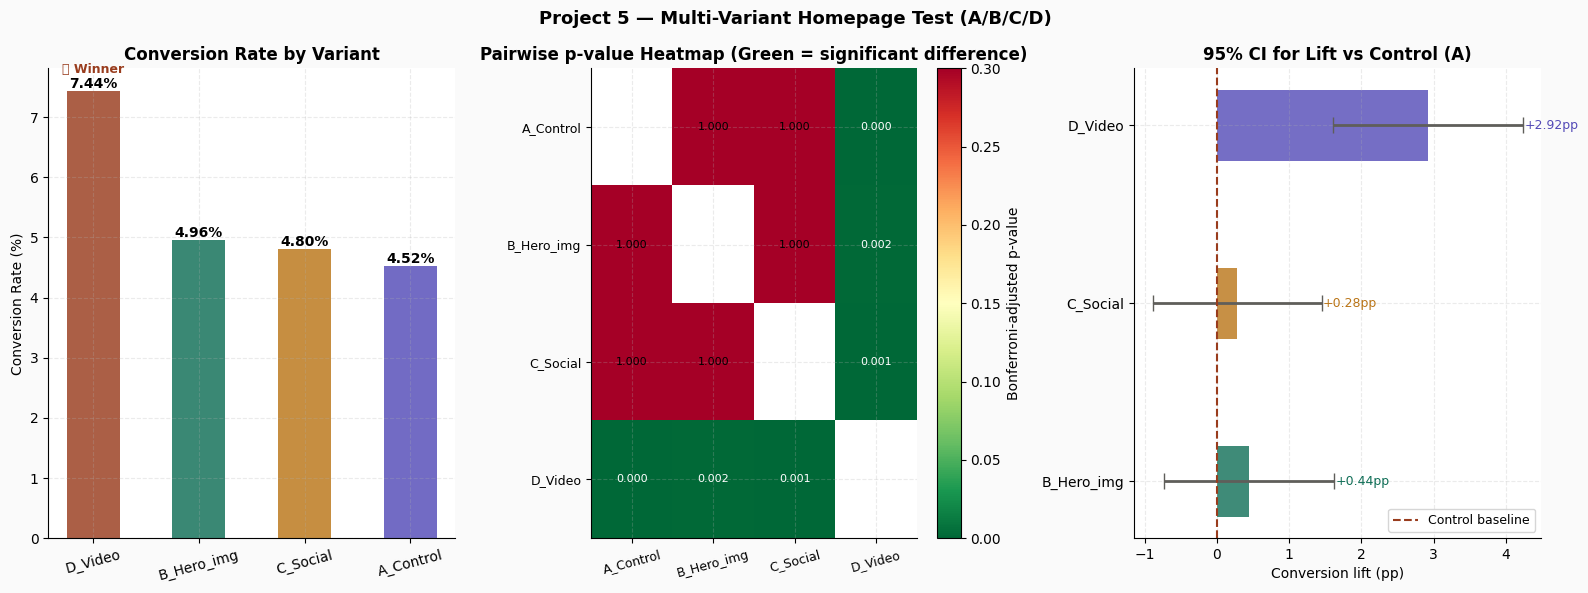

✅ Dashboard saved: p5_multivariant_ab.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Project 5 — Multi-Variant Homepage Test (A/B/C/D)', fontsize=13, fontweight='bold')

# 1. Conversion rate comparison
variants_sorted = conv_rates.index.tolist()
rates_sorted    = conv_rates['Rate_pct'].tolist()
colors_mv       = [CORAL, TEAL, AMBER, PURPLE]
bars = axes[0].bar(variants_sorted, rates_sorted, color=colors_mv, alpha=0.82, width=0.5)
for bar, v in zip(bars, rates_sorted):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Conversion Rate by Variant', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)'); axes[0].tick_params(axis='x', rotation=15)
# Add winner badge
best = variants_sorted[0]
axes[0].text(0, rates_sorted[0]+0.3, '🏆 Winner', ha='center', color=CORAL,
             fontsize=9, fontweight='bold')

# 2. Pairwise p-values heatmap - "இந்த difference உண்மையா? இல்ல random chance ஆ?"
# | Color    | Meaning                   |
# | -------- | ------------------------- |
# | 🟢 Green | Significant Difference    |
# | 🔴 Red   | No Significant Difference | A_Control vs D_Video 0.000 , Meaning: 0.000 < 0.05 ✅ Difference இருக்கு

ph_matrix = pd.DataFrame(1.0, index=variants, columns=variants)
for _, row in ph_df.iterrows():
    v1, v2 = row['pair'].split(' vs ')
    ph_matrix.loc[v1, v2] = row['adj_p']
    ph_matrix.loc[v2, v1] = row['adj_p']
ph_arr = ph_matrix.values.copy(); np.fill_diagonal(ph_arr, np.nan); ph_matrix = pd.DataFrame(ph_arr, index=ph_matrix.index, columns=ph_matrix.columns)

mask = np.zeros_like(ph_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

im = axes[1].imshow(ph_matrix.values, cmap='RdYlGn_r', vmin=0, vmax=0.3, aspect='auto')
axes[1].set_xticks(range(4)); axes[1].set_yticks(range(4))
axes[1].set_xticklabels(variants, rotation=15, fontsize=9)
axes[1].set_yticklabels(variants, fontsize=9)
for i in range(4):
    for j in range(4):
        if i != j:
            v = ph_matrix.values[i,j]
            axes[1].text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
                         color='white' if v < 0.05 else 'black')
plt.colorbar(im, ax=axes[1], label='Bonferroni-adjusted p-value')
axes[1].set_title('Pairwise p-value Heatmap (Green = significant difference)', fontweight='bold')

# 3. CI plot for all variants vs Control - "இந்த difference எவ்வளவு இருக்கலாம்?" என்பதை 95% confidence interval-ஆக காட்டுகிறது.
# "Control (A) ஐ விட எவ்வளவு improvement?"

# Vertical Red Line (0) => 0 = No Improvement
# D_Video = +2.92pp Meaning:
# 4.52%
# ↓
# 7.44% Improvement: +2.92 percentage points மேலும் error bar முழுவதும் 0-க்கு வலது பக்கம் இருக்கிறது. ✅ Real Improvement

# B_Hero_img = +0.44pp Meaning:
# 4.52%
# ↓
# 4.96% சிறிய improvement. ஆனால் error bar 0-ஐ touch/cross செய்கிறது. ❌ Significant இல்லை.

ax3 = axes[2]
ctrl_rate = df_mv[df_mv['variant']=='A_Control']['converted'].mean()
for i, (v, col) in enumerate(zip(['B_Hero_img','C_Social','D_Video'],
                                  [TEAL, AMBER, PURPLE])):
    r_v = run_ab_test(
        df_mv[df_mv['variant']=='A_Control']['converted'].sum(),
        n_var,
        df_mv[df_mv['variant']==v]['converted'].sum(),
        n_var
    )
    diff_v = (r_v['p_B'] - r_v['p_A'])*100
    ci_v   = ((r_v['ci'][0])*100, (r_v['ci'][1])*100)
    ax3.barh(i, diff_v, color=col, alpha=0.8, height=0.4)
    ax3.errorbar(diff_v, i,
                 xerr=[[diff_v-ci_v[0]],[ci_v[1]-diff_v]],
                 fmt='none', color=DGRAY, capsize=6, linewidth=2)
    ax3.text(ci_v[1]+0.02, i, f'{diff_v:+.2f}pp', va='center', fontsize=9, color=col)
ax3.axvline(0, color=CORAL, linestyle='--', linewidth=1.5, label='Control baseline')
ax3.set_yticks(range(3))
ax3.set_yticklabels(['B_Hero_img','C_Social','D_Video'])
ax3.set_title('95% CI for Lift vs Control (A)', fontweight='bold')
ax3.set_xlabel('Conversion lift (pp)'); ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('p5_multivariant_ab.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved: p5_multivariant_ab.png")


---
---
# 📋 A/B Testing Master Reference


In [11]:
print("╔" + "═"*70 + "╗")
print("║  A/B TESTING — COMPLETE PYTHON REFERENCE" + " "*29 + "║")
print("╠" + "═"*70 + "╣")
print("║  STEP 1: SAMPLE SIZE                                              ║")
print("║  n = calc_sample_size(p_baseline, mde, alpha=0.05, power=0.80)   ║")
print("║                                                                   ║")
print("║  STEP 2: RUN THE TEST                                             ║")
print("║  result = run_ab_test(conv_A, n_A, conv_B, n_B)                  ║")
print("║                                                                   ║")
print("║  STEP 3: VALIDITY                                                 ║")
print("║  # SRM check: chi2_contingency([[n_A, n_B]])                      ║")
print("║  # Normality: stats.shapiro for continuous metrics                ║")
print("║                                                                   ║")
print("║  STEP 4: WHICH TEST?                                              ║")
print("║  Conversion rates (2 groups)  → Two-proportion z-test            ║")
print("║  Categorical outcome          → Chi-square test                  ║")
print("║  Multiple variants (4 groups) → Chi-square + Bonferroni post-hoc ║")
print("║  Continuous metric (revenue)  → t-test (or Mann-Whitney)         ║")
print("║                                                                   ║")
print("║  COMMON PITFALLS                                                  ║")
print("║  ⚠️  Peeking at p-values before reaching required n               ║")
print("║  ⚠️  Running test past significance (winner's curse)              ║")
print("║  ⚠️  Choosing one-tail AFTER seeing data (p-hacking)             ║")
print("║  ⚠️  Not checking SRM before analysis                            ║")
print("║  ⚠️  Multiple tests without Bonferroni correction                ║")
print("╠" + "═"*70 + "╣")
print("║  KEY FORMULAS                                                     ║")
print("║  z     = (p_B - p_A) / sqrt(p_pool*(1-p_pool)*(1/nA+1/nB))      ║")
print("║  p_val = 2*(1 - norm.cdf(|z|))        [two-tail]                 ║")
print("║  power = norm.cdf( (effect-z_α*SE₀)/SE₁ )                       ║")
print("║  Bonferroni α_adj = α / k   where k = number of pairs            ║")
print("╚" + "═"*70 + "╝")


╔══════════════════════════════════════════════════════════════════════╗
║  A/B TESTING — COMPLETE PYTHON REFERENCE                             ║
╠══════════════════════════════════════════════════════════════════════╣
║  STEP 1: SAMPLE SIZE                                              ║
║  n = calc_sample_size(p_baseline, mde, alpha=0.05, power=0.80)   ║
║                                                                   ║
║  STEP 2: RUN THE TEST                                             ║
║  result = run_ab_test(conv_A, n_A, conv_B, n_B)                  ║
║                                                                   ║
║  STEP 3: VALIDITY                                                 ║
║  # SRM check: chi2_contingency([[n_A, n_B]])                      ║
║  # Normality: stats.shapiro for continuous metrics                ║
║                                                                   ║
║  STEP 4: WHICH TEST?                                              ║
║  Conversion

---
## 🎓 What You Learned — Stage 4 Summary

### All 5 Projects

| # | Project | Key Test | Key Concept |
|---|---------|---------|-------------|
| 1 | Button color | Two-proportion z-test | Full pipeline: MDE → n → test → ship decision |
| 2 | Pricing layout | Chi-square | Multiple categorical outcomes |
| 3 | Email subject | Proportion z-test | Peeking problem, segment analysis |
| 4 | Checkout flow | Power analysis | Type I & II errors, underpowered tests |
| 5 | Homepage variants | Chi-square + post-hoc | Multiple testing, Bonferroni correction |

### Resume Line
> *"Designed and executed end-to-end A/B testing pipelines for 5 business domains: e-commerce CTA optimisation, SaaS pricing layout, email marketing, checkout UX, and multi-variant homepage testing.  
> Applied two-proportion z-tests, chi-square tests, and Bonferroni-corrected post-hoc pairwise analysis.  
> Identified ₹X.XM annual revenue opportunity from statistically significant 0.6pp conversion lift.  
> Implemented sample size calculator and statistical power analysis to prevent underpowered experiments."*

---
### ➡️ Next: Stage 5 — ANOVA & Marketing Channel Analysis
> Compare 4 marketing channels simultaneously, post-hoc Tukey HSD, normality checks
